In [1]:
import os
import sys
import copy
import torch
import argparse
from pprint import pprint


# Import ssu packages
sys.path.append('../src')
sys.path.append('../config')
# config packages
import read_config
# src packages
from eval import ABC_eval
from models import unet
from models import model as simpleModels
from models import unet as unetModels
from training import model_training_v2 as model_training
from logger import wandb_logging
from data_loader import ABC_dataset_loader
from utils import fvdb_utils as fu
from utils import ssu_tools as st 

import torch
import gc

def clear_gpu_memory():
    """Clear all GPU memory allocated by PyTorch"""
    
    if torch.cuda.is_available():
        # Clear PyTorch cache
        torch.cuda.empty_cache()
        
        # Force garbage collection
        gc.collect()
        
        # Clear all tensors from GPU
        torch.cuda.synchronize()
        
        # Get memory info
        allocated = torch.cuda.memory_allocated() / 1e9
        cached = torch.cuda.memory_reserved() / 1e9
        
        print(f"GPU Memory - Allocated: {allocated:.2f} GB, Cached: {cached:.2f} GB")
        
        # If memory is still allocated, try more aggressive clearing
        if allocated > 0:
            print("Attempting to clear more GPU memory...")
            print("Avoiding this step")
            # torch.cuda.empty_cache()
            # torch.cuda.synchronize()
            # gc.collect()
            
        print("✅ GPU memory cleared")
    else:
        print("❌ No CUDA GPU available")

# Call this function
clear_gpu_memory()

# def main(config_file):
config_file = 'config_55_10102025_1400.yaml'
# read config file
config = read_config.read_yaml_config(f'{config_file}')

print("Configuration loaded:")
for key, value in config.items():
    pprint(f"{key}: {value}")

# initialize logging
logger = wandb_logging.WandbLogger(
                    logging=config['logging'],
                    project_name=config['wandb']['project_name'],
                    entity=config['wandb']['entity'],
                    name=config['wandb']['name'],
                    group=config['wandb']['group'],
                    tags=config['wandb']['tags'],
                    notes=config['wandb']['notes'],
                    config=config['wandb']['config'],
                    # resume="allow",
                    # id = 'z3zwr3y6'
                )
logger.update_config('config_file_name', config_file)

# set reproducibility
st.set_reproducibility(is_reproducible=config['reproducibility']['is_reproducible'],
                        seed=config['reproducibility']['seed'])

# load data
input_dir = config['data']['input_dir']
names_set = os.listdir('/data/workspaces/spanwar/dataset/preprocessing_nmc_data/data_preprocessing/get_groundtruth_NMC/gt')


### if this work ###
# 1. Add gaussian noise to the input
# 2. change the normalization
# 3. Increae the steps 10 to 20
# 4. use dataprocessing
dataLoader = ABC_dataset_loader.ABCDataLoader(
                                    input_dir=input_dir,
                                    config=config,
                                    n_samples=10
                                )
(train_dataloader, 
val_dataloader, 
test_dataloader) = dataLoader.get(names_set=names_set)
logger.update_config('data_size', len(os.listdir(input_dir)))

GPU Memory - Allocated: 0.00 GB, Cached: 0.00 GB
✅ GPU memory cleared
Configuration loaded:
'logging: True'
"reproducibility: {'is_reproducible': True, 'seed': 42}"
("data: {'input_dir': "
 "'/data/workspaces/spanwar/dataset/preprocessing_nmc_data/data_preprocessing/get_groundtruth_NMC/gt_large', "
 "'data_description': 'Generated SDF of 32, 64, 128, 256 data using NMC "
 "logic', 'data_name': 'V1_Manual_Extracted_NMC_Data_large', 'data_split': "
 "{'train': 0.6, 'val': 0.2, 'test': 0.2}, 'dataset_grids': [32, 64, 128], "
 "'mask_threshold': {32: 65, 64: 129}, 'sdf_scaling_value': {32: 65, 64: 129}, "
 "'input_size': {32: 33, 64: 65}, 'unique_random_direction': True, 'is_crop': "
 "{'train': False, 'val': False, 'test': False}, 'crops_ratio': [1, 0.5, "
 "0.25], 'crops_threshold': {32: {1: 1600, 0.5: 800, 0.25: 400}, 64: {1: 5600, "
 "0.5: 2800, 0.25: 1400}}, 'n_jobs': -1, 'batch_size': 16, 'shuffle': "
 "{'train': True, 'val': False, 'test': False}, 'num_workers': 0}")
("training: {'u

100%|██████████| 2/2 [00:00<00:00, 1903.91it/s]


In [2]:
batch = next(iter(train_dataloader))
names, input_size, input_vdb, output_vdb = batch
# (obj_names, 
#                  vdb_input_32, 
#                  vdb_input_64, 
#                  new_ijkss_32, 
#                  new_ijkss_64, 
#                  new_featuress_32, 
#                  new_featuress_64, 
#                  actual_sdfs) = batch

In [3]:
input_size

[33, 33, 33, 33, 33, 33]

In [4]:
input_vdb[0].jdata

tensor([[ 2.7381, -1.0000,  0.5000,  0.5000],
        [ 2.7105, -0.5000, -0.5000,  1.0000],
        [ 2.7105, -0.5000,  1.0000,  0.5000],
        ...,
        [ 2.7223,  1.0000,  0.0000,  0.0000],
        [ 2.5176,  0.5000, -1.0000,  0.0000],
        [ 2.7381,  0.0000,  1.0000,  0.0000]], device='cuda:0')

In [6]:
from meshplot import plot
def plot_vdb(vdb):
    v, f, _ = vdb.grid.marching_cubes(vdb.data.jdata[:, 0])
    v = v.jdata.detach().cpu().numpy()
    f = f.jdata.detach().cpu().numpy()
    plot(v,f)
plot_vdb(input_vdb[-1])

NameError: name 'input_vdb' is not defined

# check the prediction

In [1]:
import os
import fvdb
from meshplot import plot   

In [ ]:
import trimesh

def plot_vdb_with_grid_and_data(grid, data, is_save=False):
    v, f, _ = grid.marching_cubes(data)
    v = v.jdata.detach().cpu().numpy()
    f = f.jdata.detach().cpu().numpy()
    plot(v,f)
    if is_save:
        mesh = trimesh.Trimesh(vertices=v, faces=f)
        mesh.export('data/64_128_00000020.ply')
         

In [3]:
# path = '/data/workspaces/spanwar/results/ssu/test_predictions/55_improve_49_with_SDG_and_scheduler_and_64'
path = '/data/workspaces/spanwar/results/ssu/test_predictions/66_test'
path = '/data/workspaces/spanwar/results/ssu/test_predictions/66_with_custom_loss_per_change'

In [4]:
sorted(os.listdir(path))

['32_00000297.nvdb',
 '32_00000575.nvdb',
 '32_00000980.nvdb',
 '32_00001475.nvdb',
 '32_00001559.nvdb',
 '32_00001749.nvdb',
 '32_00001855.nvdb',
 '32_00002426.nvdb',
 '32_00002515.nvdb',
 '32_00002580.nvdb',
 '32_00002965.nvdb',
 '32_00003557.nvdb',
 '32_00003966.nvdb',
 '32_00004199.nvdb',
 '32_00004774.nvdb',
 '32_00004800.nvdb',
 '32_00004902.nvdb',
 '32_00004932.nvdb',
 '32_00005082.nvdb',
 '32_00005112.nvdb',
 '32_00005724.nvdb',
 '32_00005754.nvdb',
 '32_00005836.nvdb',
 '32_00006007.nvdb',
 '32_00006316.nvdb',
 '32_00006658.nvdb',
 '32_00006766.nvdb',
 '32_00007223.nvdb',
 '32_00007265.nvdb',
 '32_00007777.nvdb',
 '32_00007792.nvdb',
 '32_00007808.nvdb',
 '32_00007826.nvdb',
 '32_00007913.nvdb',
 '32_00008322.nvdb',
 '32_00009041.nvdb',
 '32_00009354.nvdb',
 '32_00009423.nvdb',
 '32_00009515.nvdb',
 '32_00009846.nvdb',
 '64_00000297.nvdb',
 '64_00000575.nvdb',
 '64_00000980.nvdb',
 '64_00001475.nvdb',
 '64_00001559.nvdb',
 '64_00001749.nvdb',
 '64_00001855.nvdb',
 '64_00002426

In [5]:
# 32_00000544
# sorted(os.listdir(path))

In [7]:
import h5py
import trimesh
import torch
gt_large_path = '/data/workspaces/spanwar/dataset/preprocessing_nmc_data/data_preprocessing/get_groundtruth_NMC/gt_large'
file_name = '00000020'
file_path = os.path.join(gt_large_path, f'{file_name}.hdf5')
gt_obj_path = f'/data/workspaces/spanwar/dataset/preprocessing_nmc_data/abc_dataset_objs/{file_name}/model.obj'
with h5py.File(file_path, 'r') as f:
    # Read specific resolutions
    sdf_128 = f['128_sdf'][:] # 128³ resolution
    sdf_64 = f['64_sdf'][:]   # 64³ resolution
    sdf_32 = f['32_sdf'][:]

import numpy as np
from skimage import measure
import meshplot as mp

# Get vertices and faces using marching cubes
vertices, faces, normals, values = measure.marching_cubes(sdf_32, level=0)
# Plot the mesh
mp.plot(vertices, faces)

# Get vertices and faces using marching cubes
vertices, faces, normals, values = measure.marching_cubes(sdf_128, level=0)
# Plot the mesh
mp.plot(vertices, faces)

# display fvdb marching cube
import sys
sys.path.append('../src')
from utils import mesh_tools  as mt 
import fvdb.nn as fvnn
grid_33 = mt.mesh_grid(33)
grid_33 = torch.tensor(grid_33)
# Create grid from coordinates
grid = fvdb.gridbatch_from_ijk(
    fvdb.JaggedTensor(grid_33),  # grid coordinates
    voxel_sizes=1/32,  # size of each voxel (33-1 = 32 divisions)
    origins=torch.tensor([0, 0, 0])  # origin of the grid
)
ijk = grid.ijk.jdata
# Create FVDB tensor from grid and SDF data
fvdb_tensor = fvnn.VDBTensor(
    grid,
    grid.jagged_like(torch.tensor(sdf_32[ijk[:, 0], ijk[:, 1], ijk[:, 2]][:, None]))  # Add channel dimension
)

v, f, _ = fvdb_tensor.grid.marching_cubes(fvdb_tensor.data)
v = v.jdata.detach().cpu().numpy()
f = f.jdata.detach().cpu().numpy()
plot(v, f)

mesh = trimesh.load(gt_obj_path)
plot(mesh.vertices, mesh.faces)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(16.0, 16.…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(64.0, 64.…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.5, 0.50…

/user/spanwar/home/.conda/envs/fvdb_ponq/lib/python3.11/site-packages/traittypes/traittypes.py:97: UserWarning: Given trait value dtype "float32" does not match required type "float64". A coerced copy has been created.
  warnings.warn(
/user/spanwar/home/.conda/envs/fvdb_ponq/lib/python3.11/site-packages/traittypes/traittypes.py:97: UserWarning: Given trait value dtype "uint32" does not match required type "float64". A coerced copy has been created.
  warnings.warn(


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

In [10]:
# 32_00004902
# 32_00000003
path = '/data/workspaces/spanwar/results/ssu/test_predictions/73_rerun_70_with_adam_5000'
grid, data, _ = fvdb.load(os.path.join(path, '32_00000020.nvdb'))
plot_vdb_with_grid_and_data(grid, data)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.5000384…

In [9]:
# # 32_00004902
# path = '/data/workspaces/spanwar/results/ssu/test_predictions/70_test'
# grid, data, _ = fvdb.load(os.path.join(path, '32_00000020.nvdb'))
# plot_vdb_with_grid_and_data(grid, data)

In [9]:
path = '/data/workspaces/spanwar/results/ssu/test_predictions/66_original_improve_inference'
grid, data, _ = fvdb.load(os.path.join(path, '32_00000020.nvdb'))
plot_vdb_with_grid_and_data(grid, data)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.4998131…

In [11]:
path = '/data/workspaces/spanwar/results/ssu/test_predictions/73_rerun_70_with_adam_5000'
grid, data, _ = fvdb.load(os.path.join(path, '32_00000003.nvdb'))
plot_vdb_with_grid_and_data(grid, data)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.5000407…

In [ ]:
path = '/data/workspaces/spanwar/results/ssu/test_predictions/66_test_weighted_loss_e_1'
grid, data, _ = fvdb.load(os.path.join(path, '32_00000020.nvdb'))
plot_vdb_with_grid_and_data(grid, data)

RuntimeError: Unable to open file named "/data/workspaces/spanwar/results/ssu/test_predictions/66_test_we50_rerun_49_with_300_epochsighted_loss_e_1/32_00000020.nvdb" for input: iostream error

In [11]:
grid, data, _ = fvdb.load(os.path.join(path, '32_00000020.nvdb'))
plot_vdb_with_grid_and_data(grid, data)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.4996708…

In [12]:
grid, data, _ = fvdb.load(os.path.join(path, '64_00000020.nvdb'))
plot_vdb_with_grid_and_data(grid, data, is_save=True)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.4998073…

In [33]:
# display the ply file  
import trimesh
from meshplot import plot
mesh = trimesh.load('/user/spanwar/home/Documents/learn-fvdb/ssu/SSU/comparision/reach_for_the_spheres.ply')
plot(mesh.vertices, mesh.faces)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.000373…

In [18]:
mesh = trimesh.load('/user/spanwar/home/Documents/learn-fvdb/ssu/SSU/comparision/reach_for_the_arcs.ply')
plot(mesh.vertices, mesh.faces)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.000292…

# Download mesh

In [34]:
import numpy as np
def NDCnormalize(vertices, return_scale=False):
    """normalization in half unit ball"""
    vM = vertices.max(0)
    vm = vertices.min(0)
    scale = np.sqrt(((vM - vm) ** 2).sum(-1))
    mean = (vM + vm) / 2.0
    nverts = (vertices - mean) / scale
    if return_scale:
        return nverts, mean, scale
    return nverts

In [ ]:
import os
import fvdb
import trimesh

prediction_dir = '/data/workspaces/spanwar/results/ssu/test_predictions/73_rerun_70_with_adam_5000'
def get_test_prediction(obj_name, pred_dir):
    pred_vdb = fvdb.load(os.path.join(pred_dir, obj_name))
    v, f, _ = pred_vdb[0].marching_cubes(pred_vdb[1])
    mesh = trimesh.Trimesh(vertices=v.jdata.numpy(), faces=f.jdata.numpy())
    return mesh

mesh = get_test_prediction('32_00009742.nvdb', prediction_dir)
mesh.vertices[:] = mesh.vertices - 0.5
mesh.export('data/73_' + '32_00009742' + '.PLY') 

b'ply\nformat binary_little_endian 1.0\ncomment https://github.com/mikedh/trimesh\nelement vertex 2282\nproperty float x\nproperty float y\nproperty float z\nelement face 4560\nproperty list uchar int vertex_indices\nend_header\n7\xfa\x06\xbc\x00\x00\xa0\xbd\x00\x00\xe4\xbe\x00\x00\x00\xbc\xbc\x13\xae\xbd\x00\x00\xe4\xbe\x00\x00\x00\xbc\x00\x00\xa0\xbd4\x91\xe5\xbe\x00\x00\x00\xbc\xf5\xa5\x9a\xbd\x00\x00\xe4\xbe\x00\x00\x00\xbc\x00\x00\xb0\xbd\xaeK\xe3\xbeE\xdb\x04\xbc\x00\x00\xb0\xbd\x00\x00\xe0\xbe\x00\x00\x00\xbc\xc4\xa5\xb0\xbd\x00\x00\xe0\xbe\xa0R\x0e\xbc\x00\x00\xb0\xbd\x00\x00\xdc\xbe\x00\x00\x00\xbc\xd8\xed\xb1\xbd\x00\x00\xdc\xbe\x85\xcf\x14\xbc\x00\x00\xb0\xbd\x00\x00\xd8\xbe\x00\x00\x00\xbc\x08\x02\xb3\xbd\x00\x00\xd8\xbe\x92\t)\xbc\x00\x00\xb0\xbd\x00\x00\xd4\xbe\x00\x00\x00\xbc\x0c\xd2\xb5\xbd\x00\x00\xd4\xbe\xa2\xfc0\xbc\x00\x00\xb0\xbd\x00\x00\xd0\xbe\x00\x00\x00\xbc\xf2\xc2\xb6\xbd\x00\x00\xd0\xbe}s7\xbc\x00\x00\xb0\xbd\x00\x00\xcc\xbe\x00\x00\x00\xbc\x7f:\xb8\xbd\x00\x

# Iterative run

In [11]:
import copy
pretrained_model =  torch.load('/data/workspaces/spanwar/results/ssu/save_models/73_rerun_70_with_adam_5000.pth')
model = copy.deepcopy(pretrained_model)
model = model.to('cuda')
model.eval()

/tmp/ipykernel_321623/3096573397.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  pretrained_model =  torch.load('/data/workspaces/spanwar/results/ssu/save_models/73_reru

FVDBUNetBase(
  (conv0p1s1): SparseConv3d(4, 32, kernel_size=(5, 5, 5), bias=False)
  (bn0): BatchNorm(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv1p1s2): SparseConv3d(32, 32, kernel_size=(2, 2, 2), stride=(2, 2, 2), bias=False)
  (bn1): BatchNorm(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (block1): Sequential(
    (0): BasicBlock(
      (conv1): SparseConv3d(32, 32, kernel_size=(3, 3, 3))
      (norm1): BatchNorm(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): SparseConv3d(32, 32, kernel_size=(3, 3, 3))
      (norm2): BatchNorm(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
    )
    (1): BasicBlock(
      (conv1): SparseConv3d(32, 32, kernel_size=(3, 3, 3))
      (norm1): BatchNorm(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): SparseConv3d(32, 32, kernel_size=(3, 3, 3))
      (norm2): BatchNorm(32, eps=

In [12]:
def get_new_positions(vdb_tensor, size, upsample_factor):
    m3g = torch.tensor(mt.mesh_grid(upsample_factor+1), device=vdb_tensor.device) - (upsample_factor//2)

    new_ijks = []
    new_features = []
    for mg in m3g:
        ijk = vdb_tensor.grid.ijk.jdata
        ijk = (upsample_factor * ijk + mg).view(-1, 3)
        ijk = np.clip(ijk.cpu().detach().numpy(), 0, (size-1)*upsample_factor)
        ijk_vector = ijk - (vdb_tensor.grid.ijk.jdata.cpu().detach().numpy() * upsample_factor)
        ijk_vector = ijk_vector / (upsample_factor // 2)  # Normalize to values between -1 and 1
        ijk_vector = torch.tensor(ijk_vector, dtype=torch.float32, device=vdb_tensor.device)

        new_features.append(torch.cat([vdb_tensor.data.jdata, ijk_vector], axis=-1))
        new_ijks.append(torch.tensor(ijk, dtype=torch.int, device=vdb_tensor.device))
    return new_features, new_ijks

In [13]:
def eval_fm_steps(input_vdbs, model, n_steps=4):
    """
    Midpoint (RK2) integrator over time t in [0, 1], updating ONLY the first channel (SDF).
    Assumes:
      - input_vdbs.jdata shape = [num_samples, C]
      - channel 0 is the scalar SDF value we integrate
      - we will append a time feature t as the LAST channel
      - model(input_vdbs) returns a VDBTensor with .jdata shaped [num_samples, 1] (dSDF/dt)
    """
    def append_feature(vdb, feature_col):
        concat = torch.cat([vdb.jdata, feature_col], dim=-1)
        return fvnn.VDBTensor(vdb.grid, vdb.grid.jagged_like(concat))

    def replace_jdata(vdb, new_jdata):
        # Re-wrap to keep jagged layout correct
        return fvnn.VDBTensor(vdb.grid, vdb.grid.jagged_like(new_jdata))

    device = input_vdbs.jdata.device
    dtype  = input_vdbs.jdata.dtype

    # Time setup
    dt = 1.0 / n_steps
    # Create t column (start at 0). Make it 2D so concat works: [N,1]
    t_col = torch.zeros((input_vdbs.jdata.shape[0], 1), device=device, dtype=dtype)

    # Append time as LAST channel
    vdb = append_feature(input_vdbs, t_col)

    for step in range(n_steps):
        # Current time as scalar and as column
        t_scalar = step * dt
        t_curr = torch.full_like(t_col, t_scalar)

        # Set t in-place as LAST channel
        vdb_j = vdb.jdata
        vdb_j[:, -1] = t_curr.squeeze(-1)
        vdb = replace_jdata(vdb, vdb_j)

        # ---- k1 at (x, t) ----
        # Take current SDF values
        x_curr = vdb.jdata[:, 0:1]  # [N,1]
        k1 = model(vdb).jdata       # [N,1]  -> dSDF/dt

        # ---- midpoint state ----
        x_mid = x_curr + 0.5 * dt * k1
        t_mid = t_scalar + 0.5 * dt

        # Build a temp VDBTensor with SDF replaced by x_mid and time set to t_mid
        vdb_mid_j = vdb.jdata.clone()
        vdb_mid_j[:, 0] = x_mid.squeeze(-1)            # replace SDF channel with midpoint guess
        vdb_mid_j[:, -1] = t_mid                       # set time to midpoint
        vdb_mid = replace_jdata(vdb, vdb_mid_j)

        # ---- k2 at (x_mid, t_mid) ----
        k2 = model(vdb_mid).jdata  # [N,1]

        # ---- final update ----
        x_next = x_curr + dt * k2

        # Write back updated SDF into vdb
        vdb_next_j = vdb.jdata.clone()
        vdb_next_j[:, 0] = x_next.squeeze(-1)
        vdb = replace_jdata(vdb, vdb_next_j)

    # Return only the predicted SDF channel as a VDBTensor with single channel
    out = fvnn.VDBTensor(
        vdb.grid,
        vdb.grid.jagged_like(vdb.jdata[:, 0:1])
    )
    return out

In [14]:
def fetch_numpy_values(grid: fvdb.GridBatch, arr: np.array, size:int):
    '''fetches values from a numpy array based on the ijk indices in the grid'''
    ijk = grid.ijk.jdata.cpu().detach().numpy()
    
    if max(ijk[:, 0]) >= arr.shape[0] or max(ijk[:, 1]) >= arr.shape[1] or max(ijk[:, 2]) >= arr.shape[2]:
        # If indices are out of bounds, we can add the maximum value to the indices
        ijk = np.clip(ijk, 0, np.array(arr.shape) - 1)
        # print(f"Indices out of bounds. Clipping to max shape: {arr.shape}")
    
    values = arr[ijk[:, 0], ijk[:, 1], ijk[:, 2]]
    return torch.tensor(values, dtype=torch.float32, device=grid.device)

def fetch_numpy_values_shifted(ijk, arr: np.array):
    '''fetches values from a numpy array based on the ijk indices in the grid'''
    ijk = ijk.cpu().detach().numpy()
    values = arr[ijk[:, 0], ijk[:, 1], ijk[:, 2]]
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    return torch.tensor(values, dtype=torch.float32, device=device)

def custom_subdivide_grid(grid: fvdb.GridBatch, scale, m3g, upshape):
    '''custom subdivision of a grid to create a finer grid:
        [0,    1,    2] -->
        [0, 1, 2, 3, 4]'''
    ijk = grid.ijk.jdata
    # m3g = torch.tensor(mt.mesh_grid(3),device=grid.device)-1
    new_ijk = (scale*ijk[:, None, :]+ m3g[None, :, :]).view(-1, 3)
    new_ijk = np.clip(new_ijk, 0, upshape-1)
    return fvdb.gridbatch_from_ijk(fvdb.JaggedTensor(new_ijk), origins=grid.origins, voxel_sizes=grid.voxel_sizes/2)

def scaled_sdf(sdf_arr: np.array, sdf_scaling_value: float):
    '''scales the SDF array by the threshold value'''
    return (sdf_scaling_value-1)*sdf_arr[:, None]

In [15]:
mask = mt.make_mask_close(sdf_32, 65)
size = 33
ijk_mesh_grid = mt.mesh_grid(size)
ijk_mesh_grid = ijk_mesh_grid.reshape(size, size, size, 3)
ijk = torch.tensor(ijk_mesh_grid[mask], 
                    dtype=torch.int, 
                    device='cuda')
grid = fvdb.gridbatch_from_ijk(fvdb.JaggedTensor(ijk), 
                                voxel_sizes=(1/(size-1)), 
                                origins=torch.tensor([0, 0, 0], 
                                device='cuda'))

sdf_values = fetch_numpy_values(grid, sdf_32, size)
sdf_values = scaled_sdf(sdf_values, 65)
input_tensor = fvnn.VDBTensor(grid, grid.jagged_like(sdf_values))

In [16]:
import time
def produce_results(model, vdb_tensor, size, upscale_factor=4):
    model.eval()
    with torch.no_grad():
        upscale_shape = (upscale_factor * (size-1) + 1, upscale_factor * (size-1) + 1, upscale_factor * (size-1) + 1)
        sdf = np.full(upscale_shape, 100.0)
        new_features, ijks = get_new_positions(vdb_tensor, size, upscale_factor)
        new_vdb_tensors = []
        for new_feature, ijk in zip(new_features, ijks):
            new_vdb_tensors.append(fvnn.VDBTensor(vdb_tensor.grid,
                vdb_tensor.grid.jagged_like(new_feature)
            ))

        new_vdb_tensors = fvdb.jcat(new_vdb_tensors)
        # preds = eval_fm_steps(new_vdb_tensors, model, 10)
        preds = model(new_vdb_tensors)
        
        pred_ijk = preds.grid.ijk.jdata.cpu().detach().numpy()
        pred_values = preds.jdata.detach().cpu().numpy().squeeze()  # Remove extra dimension
        vector = new_vdb_tensors.jdata[:, 1:4].cpu().detach().numpy()  
        pred_ijk = (pred_ijk)*upscale_factor + (vector*(upscale_factor//2)).astype(int)
        sdf[pred_ijk[:, 0], pred_ijk[:, 1], pred_ijk[:, 2]] = pred_values
        
        # print(sdf.shape)
        # vertices, faces, normals, values = measure.marching_cubes(sdf, level=0)
        # # Plot the mesh
        # mp.plot(vertices, faces)
        
        # means predictions
        D, H, W = sdf.shape
        flat_idx = np.ravel_multi_index(pred_ijk.T, sdf.shape)  # (N,)

        sum_arr = np.zeros(sdf.size, dtype=np.float32)
        cnt_arr = np.zeros(sdf.size, dtype=np.int64)

        np.add.at(sum_arr, flat_idx, pred_values)     # accumulate sums per voxel
        np.add.at(cnt_arr, flat_idx, 1)               # accumulate counts per voxel

        mask = cnt_arr > 0
        mean_arr = np.zeros_like(sum_arr, dtype=np.float32)
        mean_arr[mask] = sum_arr[mask] / cnt_arr[mask]

        sdf.flat[mask] = mean_arr[mask] 
        
        sdf_mask = np.abs(sdf) < 100

        # create a fvdb tensor from the sdf
        grid = fvdb.gridbatch_from_ijk(
                fvdb.JaggedTensor(torch.tensor(np.array(np.where(sdf_mask)).T)),
                voxel_sizes=(1/(upscale_shape[0]-1)),
                origins=torch.tensor([0, 0, 0])
            )
        new_ijk = grid.ijk.jdata.cpu().detach().numpy()
        values = sdf[new_ijk[:, 0], new_ijk[:, 1], new_ijk[:, 2]]
        sdf_tensor = fvnn.VDBTensor(
            grid,
            grid.jagged_like(torch.tensor(values))
        )
        
    return sdf_tensor

In [17]:
sdf_tensor = produce_results(model, input_tensor, size, upscale_factor=4)


In [18]:
sdf_tensor.jdata.shape

torch.Size([163068])

In [22]:
pdata = (sdf_tensor.jdata/128)
index = pdata < (3/256)

# Extract ijk indices on CPU (avoid keeping CUDA tensors when converting to numpy)
ijk_t = sdf_tensor.grid.ijk.jdata[index]              # may be on CUDA
ijk_np = ijk_t.cpu().detach().numpy().astype(np.int32)  # numpy on host
# Create a CPU torch tensor for fvdb.JaggedTensor
ijk_cpu = torch.tensor(ijk_np, dtype=torch.int32, device='cuda')

# Extract values and move to CPU
values_t = sdf_tensor.jdata[index].unsqueeze(-1)

sdf = np.full((129, 129, 129), 100.0, dtype=np.float32)
sdf[ijk_np[:, 0], ijk_np[:, 1], ijk_np[:, 2]] = values_t.numpy().squeeze()

# Build grid using CPU tensors/origins (avoid CUDA->numpy conversions inside fvdb)

grid = fvdb.gridbatch_from_ijk(
    fvdb.JaggedTensor(ijk_cpu),
    voxel_sizes=(1/128),
    origins=torch.tensor([0, 0, 0], device='cuda')
)

# Index the numpy sdf with CPU numpy indices
ijk2 = grid.ijk.jdata.cpu().detach().numpy()
values = sdf[ijk2[:, 0], ijk2[:, 1], ijk2[:, 2]]

# Wrap values as a CPU torch tensor before making a VDBTensor
new_sdf_tensor = fvnn.VDBTensor(
    grid,
    grid.jagged_like(torch.tensor(values, dtype=torch.float32, device='cuda').unsqueeze(-1))
)

sdf_tensor = produce_results(model, new_sdf_tensor, 129, upscale_factor=2)

In [23]:
plot_vdb_with_grid_and_data(input_tensor.grid, input_tensor.data)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.5, 0.50…

In [24]:
plot_vdb_with_grid_and_data(sdf_tensor.grid, sdf_tensor.data)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.5011308…

In [37]:
# plot_vdb_with_grid_and_data(sdf_tensor.grid, sdf_tensor.data)

# Distribution

In [11]:
import h5py
import trimesh
import os
gt_large_path = '/data/workspaces/spanwar/dataset/preprocessing_nmc_data/data_preprocessing/get_groundtruth_NMC/gt_large'
file_name = '00000020'
file_path = os.path.join(gt_large_path, f'{file_name}.hdf5')
gt_obj_path = f'/data/workspaces/spanwar/dataset/preprocessing_nmc_data/abc_dataset_objs/{file_name}/model.obj'
with h5py.File(file_path, 'r') as f:
    # Read specific resolutions
    sdf_128 = f['128_sdf'][:] # 128³ resolution
    sdf_32 = f['32_sdf'][:]

In [17]:
import os
import fvdb
import torch
from meshplot import plot   
path = '/data/workspaces/spanwar/results/ssu/test_predictions/70_test'
grid, data, _ = fvdb.load(os.path.join(path, f'32_{file_name}.nvdb'))
# plot_vdb_with_grid_and_data(grid, data)
ijk = grid.ijk.jdata
act_sdf_val = sdf_128[ijk[:, 0], ijk[:, 1], ijk[:, 2]]*64
pred_sdf_val = data.jdata

ijk = ijk//4
ijk, inv, counts = torch.unique(ijk, dim=0, return_inverse=True, return_counts=True)
print(ijk)
inp_sdf_val = sdf_32[ijk[:, 0], ijk[:, 1], ijk[:, 2]]*64

tensor([[11,  2, 15],
        [11,  2, 16],
        [11,  3, 13],
        ...,
        [20, 27, 18],
        [20, 27, 19],
        [20, 27, 20]], dtype=torch.int32)


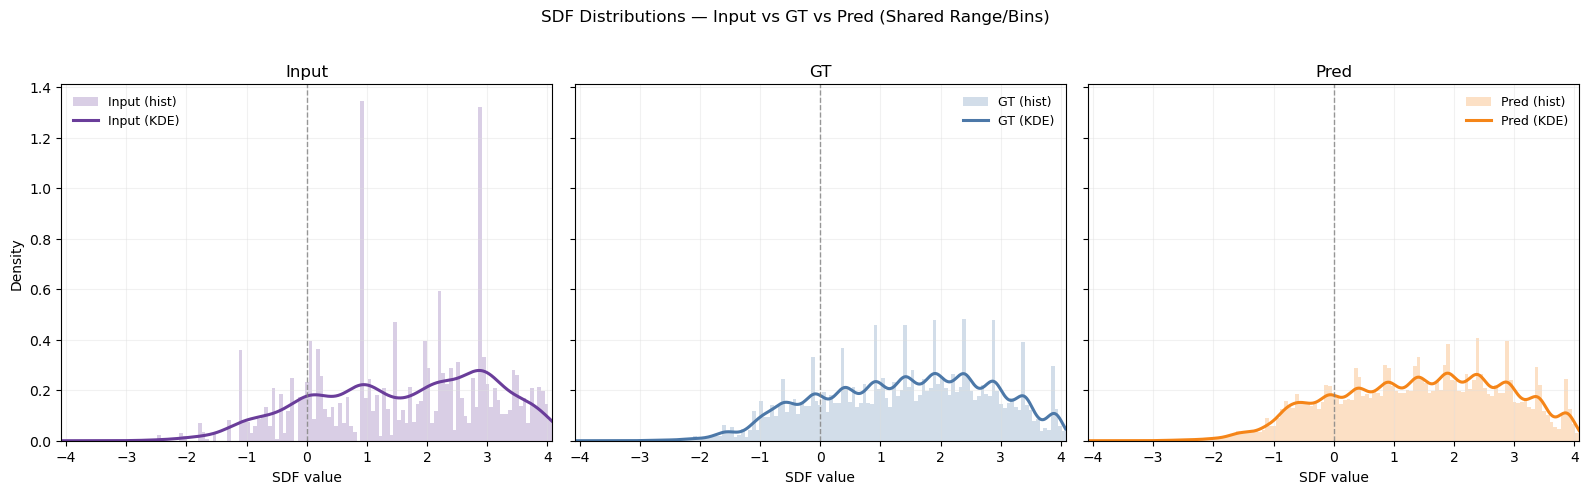

N (GT) = 163068 | N (Pred) = 163068 | N (Input×65) = 3375


In [18]:
import numpy as np
import matplotlib.pyplot as plt

# --- Assume you've already computed these arrays ---
# act_sdf_val, pred_sdf_val, inp_sdf_val (input was scaled by 65 earlier)

gt   = np.asarray(act_sdf_val,  float).ravel()
pred = np.asarray(pred_sdf_val, float).ravel()
inp  = np.asarray(inp_sdf_val,  float).ravel()

# Clean invalids independently
gt   = gt[np.isfinite(gt)]
pred = pred[np.isfinite(pred)]
inp  = inp[np.isfinite(inp)]

# Colors (distinct per panel)
colors = {"gt":"#4C78A8", "pred":"#F58518", "inp":"#6A3D9A", "grid":"0.87"}

# Global symmetric range (trim tails so details show)
all_vals = np.concatenate([x for x in [gt, pred, inp] if x.size])
lo = np.percentile(all_vals, 0.5)
hi = np.percentile(all_vals, 99.5)
rng = max(abs(lo), abs(hi))
hist_range = (-rng, rng) if np.isfinite(rng) and rng > 0 else (
    -max(np.max(np.abs(all_vals)), 1.0), max(np.max(np.abs(all_vals)), 1.0)
)

# Adaptive bins (Freedman–Diaconis)
def fd_bins(a, vrange):
    a = a[(a >= vrange[0]) & (a <= vrange[1])]
    if a.size < 2:
        return 60
    iqr = np.subtract(*np.percentile(a, [75, 25]))
    if iqr == 0:
        return 200
    h = 2 * iqr / np.cbrt(a.size)
    return max(60, int(np.ceil((vrange[1] - vrange[0]) / h)))

bins = fd_bins(all_vals, hist_range)

# Smooth line helper: KDE if SciPy available; else Gaussian-smoothed hist
def smooth_line(ax, samples, vrange, bins, label, color):
    try:
        from scipy.stats import gaussian_kde
        xs = np.linspace(vrange[0], vrange[1], 1024)
        data = samples[(samples >= vrange[0]) & (samples <= vrange[1])]
        if data.size > 1:
            kde = gaussian_kde(data)
            ys = kde(xs)
            ax.plot(xs, ys, lw=2.2, color=color, label=f"{label} (KDE)")
    except Exception:
        counts, edges = np.histogram(samples, bins=bins, range=vrange, density=True)
        centers = 0.5*(edges[1:] + edges[:-1])
        sigma_bins = 1.8
        rad = int(np.ceil(3*sigma_bins))
        kx = np.arange(-rad, rad+1)
        k = np.exp(-(kx**2)/(2*sigma_bins**2)); k /= k.sum()
        smoothed = np.convolve(counts, k, mode="same")
        ax.plot(centers, smoothed, lw=2.2, color=color, label=f"{label} (smoothed)")

def draw_panel(ax, samples, label, color):
    if samples.size == 0:
        ax.text(0.5, 0.5, f"No data: {label}", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
        return
    ax.hist(samples, bins=bins, range=hist_range, density=True,
            alpha=0.25, color=color, edgecolor="none", label=f"{label} (hist)")
    smooth_line(ax, samples, hist_range, bins, label, color)
    ax.axvline(0, ls="--", lw=1, color="0.5", alpha=0.8)
    ax.set_xlim(hist_range)
    ax.grid(True, alpha=0.4, color=colors["grid"])
    ax.set_title(label)
    ax.legend(frameon=False, fontsize=9)

# --- Side-by-side figure ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), sharex=True, sharey=True)
draw_panel(axes[0], inp,  "Input",  colors["inp"])
draw_panel(axes[1], gt,   "GT",        colors["gt"])
draw_panel(axes[2], pred, "Pred",      colors["pred"])

# Labels on outer
axes[0].set_ylabel("Density")
for ax in axes:
    ax.set_xlabel("SDF value")

fig.suptitle("SDF Distributions — Input vs GT vs Pred (Shared Range/Bins)", y=1.02, fontsize=12)
fig.tight_layout()
plt.show()

print(f"N (GT) = {gt.size} | N (Pred) = {pred.size} | N (Input×65) = {inp.size}")


MAE=0.038521  RMSE=0.054428  Bias=0.008308  N=163068
Near-surface (|SDF|<0.02): N=832  RMSE=0.067606


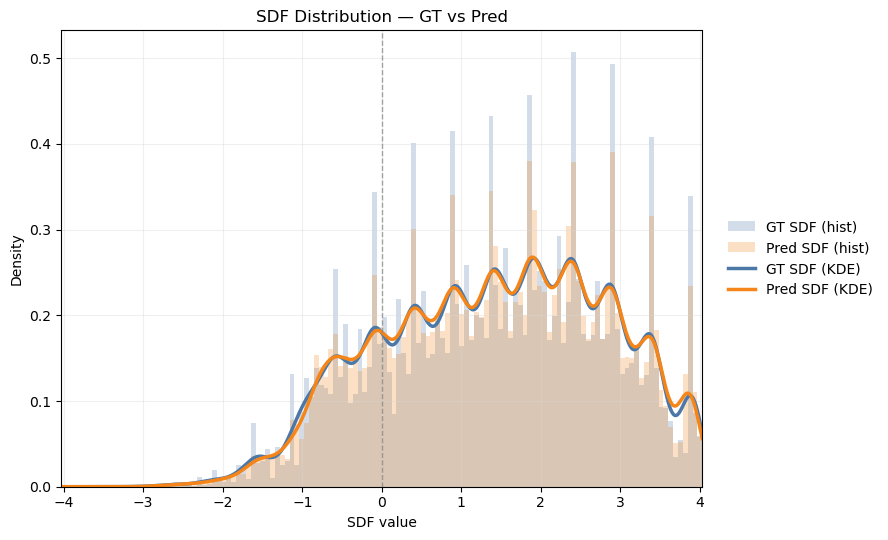

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


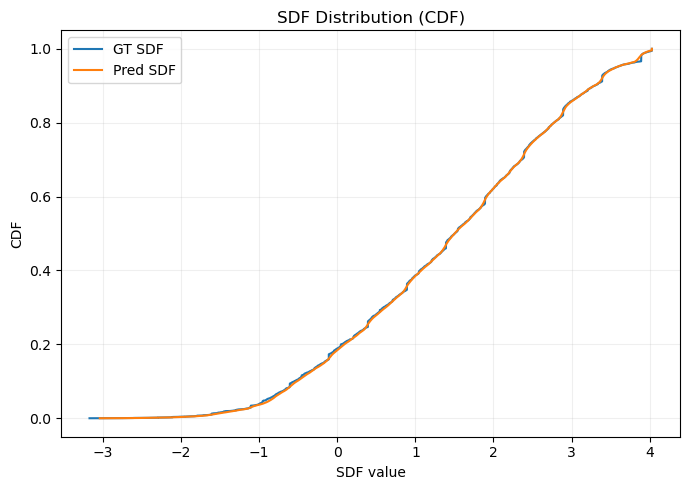

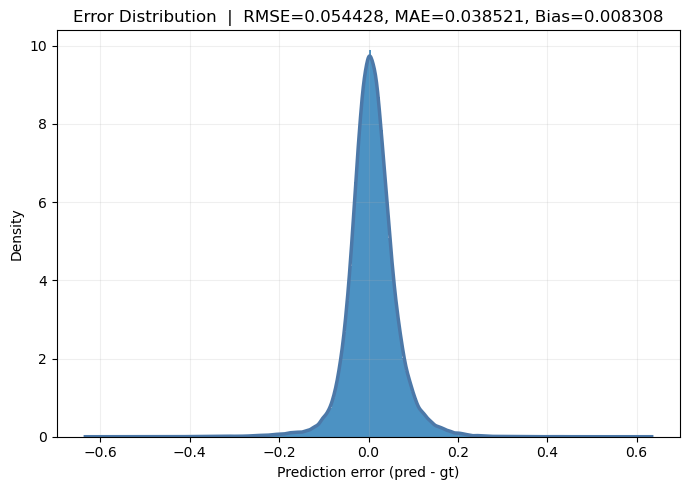

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


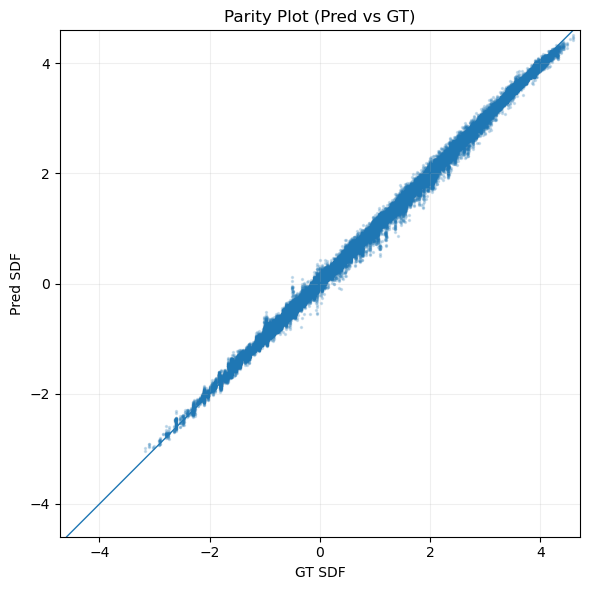

In [19]:
import numpy as np
import matplotlib.pyplot as plt
# import seaborn as sns

# 0) Clean + common range
y = np.asarray(act_sdf_val).astype(float).ravel()
yhat = np.asarray(pred_sdf_val).astype(float).ravel()
inp  = np.asarray(inp_sdf_val,  float).ravel()

m = np.isfinite(y) & np.isfinite(yhat)
y, yhat = y[m], yhat[m]

# Common histogram range (symmetric if SDF)
rng = np.max(np.abs(np.concatenate([y, yhat]))) if y.size else 1.0
hist_range = (-rng, rng)

# 1) Summary stats
err = yhat - y
mae = np.mean(np.abs(err))
rmse = np.sqrt(np.mean(err**2))
bias = np.mean(err)
print(f"MAE={mae:.6f}  RMSE={rmse:.6f}  Bias={bias:.6f}  N={len(y)}")

# Near-surface mask (optional): focus on band around 0
band = 0.02  # 2 cm if units are meters; adjust as needed
ms = np.abs(y) < band
print(f"Near-surface (|SDF|<{band}): N={ms.sum()}  RMSE={np.sqrt(np.mean((yhat[ms]-y[ms])**2)):.6f}")


# --- pleasant colors (edit to taste)
colors = {
    "gt":   "#4C78A8",  # blue
    "pred": "#F58518",  # orange
    "grid": "0.85"
}

# --- trimmed symmetric range so tails don't crush detail
lo = np.percentile(np.concatenate([y, yhat]), 0.5)
hi = np.percentile(np.concatenate([y, yhat]), 99.5)
rng = max(abs(lo), abs(hi)) if np.isfinite([lo, hi]).all() else max(np.max(np.abs(y)), np.max(np.abs(yhat)))
hist_range = (-rng, rng)

# --- Freedman–Diaconis bins (adaptive)
def fd_bins(a, vrange):
    a = a[(a >= vrange[0]) & (a <= vrange[1])]
    if a.size < 2:
        return 60
    iqr = np.subtract(*np.percentile(a, [75, 25]))
    if iqr == 0:
        return 200
    h = 2 * iqr / np.cbrt(a.size)
    return max(60, int(np.ceil((vrange[1] - vrange[0]) / h)))

bins = fd_bins(np.concatenate([y, yhat]), hist_range)

# --- KDE if SciPy exists; else smooth histogram
def smooth_line(samples, vrange, bins, label, color):
    xs = None
    try:
        from scipy.stats import gaussian_kde
        xs = np.linspace(vrange[0], vrange[1], 1024)
        kde = gaussian_kde(samples[(samples >= vrange[0]) & (samples <= vrange[1])])
        ys = kde(xs)
        plt.plot(xs, ys, lw=2.5, color=color, label=f"{label} (KDE)")
    except Exception:
        counts, edges = np.histogram(samples, bins=bins, range=vrange, density=True)
        centers = 0.5 * (edges[1:] + edges[:-1])
        # simple Gaussian smoothing
        sigma_bins = 1.5
        rad = int(np.ceil(3 * sigma_bins))
        kx = np.arange(-rad, rad + 1)
        k = np.exp(-(kx**2) / (2 * sigma_bins**2))
        k = k / k.sum()
        smoothed = np.convolve(counts, k, mode="same")
        plt.plot(centers, smoothed, lw=2.5, color=color, label=f"{label} (smoothed)")

plt.figure(figsize=(9, 5.5))

# light histograms for context
plt.hist(y,    bins=bins, range=hist_range, density=True, alpha=0.25, color=colors["gt"],   edgecolor="none", label="GT SDF (hist)")
plt.hist(yhat, bins=bins, range=hist_range, density=True, alpha=0.25, color=colors["pred"], edgecolor="none", label="Pred SDF (hist)")

# smooth overlay lines
smooth_line(y,    hist_range, bins, "GT SDF",   colors["gt"])
smooth_line(yhat, hist_range, bins, "Pred SDF", colors["pred"])

# style & labels
plt.axvline(0, ls="--", lw=1, color="0.5", alpha=0.7)
plt.xlim(hist_range)
plt.xlabel("SDF value")
plt.ylabel("Density")
plt.title("SDF Distribution — GT vs Pred")
plt.grid(True, alpha=0.4, color=colors["grid"])
plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)
plt.tight_layout()
plt.show()

# 3) CDFs
def ecdf(a):
    a = np.sort(a)
    x = a
    y = np.linspace(0, 1, len(a), endpoint=True)
    return x, y

x1, F1 = ecdf(np.clip(y, *hist_range))
x2, F2 = ecdf(np.clip(yhat, *hist_range))
plt.figure(figsize=(7,5))
plt.plot(x1, F1, label="GT SDF")
plt.plot(x2, F2, label="Pred SDF")
plt.xlabel("SDF value")
plt.ylabel("CDF")
plt.title("SDF Distribution (CDF)")
plt.legend()
plt.grid(True, alpha=0.2)
plt.tight_layout()

# 4) Error histogram
plt.figure(figsize=(7,5))
err_rng = np.max(np.abs(err)) if err.size else 1.0
plt.hist(err, bins=200, range=(-err_rng, err_rng), density=True, alpha=0.8)
plt.xlabel("Prediction error (pred - gt)")
plt.ylabel("Density")
plt.title(f"Error Distribution  |  RMSE={rmse:.6f}, MAE={mae:.6f}, Bias={bias:.6f}")
bins=200
hist_range=(-err_rng, err_rng)
smooth_line(err,    hist_range, bins, "pred error",   colors["gt"])
plt.grid(True, alpha=0.2)
plt.tight_layout()

# 5) Parity plot (ŷ vs y)
plt.figure(figsize=(6,6))
# sample if huge
idx = np.random.choice(len(y), size=min(200000, len(y)), replace=False) if len(y) > 200000 else slice(None)
ys, yhats = y[idx], yhat[idx]
lim = max(np.max(np.abs(ys)), np.max(np.abs(yhats)))
plt.scatter(ys, yhats, s=2, alpha=0.2)
plt.plot([-lim, lim], [-lim, lim], lw=1)
plt.xlabel("GT SDF")
plt.ylabel("Pred SDF")
plt.title("Parity Plot (Pred vs GT)")
plt.axis("equal")
plt.xlim(-lim, lim)
plt.ylim(-lim, lim)
plt.grid(True, alpha=0.2)
plt.tight_layout()

plt.show()


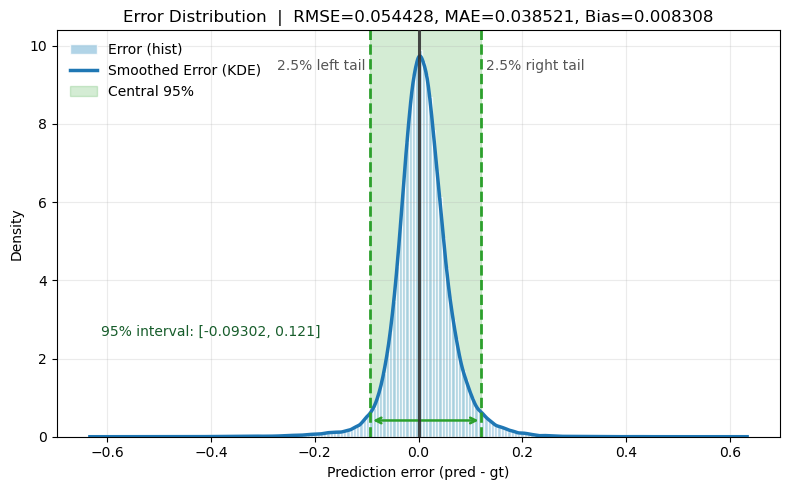

In [20]:
# 95% central interval via quantiles
p_lo, p_hi = np.quantile(err, [0.025, 0.975])
inside     = np.mean((err >= p_lo) & (err <= p_hi))
left_tail  = np.mean(err < p_lo)
right_tail = np.mean(err > p_hi)

# Range/bins (keep your style)
err_rng = np.max(np.abs(err)) if err.size else 1.0
bins = 200
hist_range = (-err_rng, err_rng)

# Accent color for the 95% interval
accent = "#2ca02c"  # pleasant green
# ... keep all your existing code above ...

plt.figure(figsize=(8,5))
counts, edges, _ = plt.hist(
    err, bins=bins, range=hist_range, density=True,
    alpha=0.8, color="#9ecae1", edgecolor="white", label="Error (hist)"
)

# Smooth overlay
try:
    smooth_line(err, hist_range, bins, "Smoothed Error", "#1f77b4")
except Exception:
    pass

# Shade the central 95%
plt.axvspan(p_lo, p_hi, color=accent, alpha=0.20, zorder=0, label="Central 95%")
plt.axvline(p_lo, color=accent, ls="--", lw=2)
plt.axvline(p_hi, color=accent, ls="--", lw=2)

ax = plt.gca()
ymin, ymax = ax.get_ylim()
y = ymin + 0.04*(ymax - ymin)

# Pretty bracket + label
ax.annotate("", xy=(p_lo, y), xytext=(p_hi, y),
            arrowprops=dict(arrowstyle="<->", lw=1.8, color=accent), annotation_clip=False)
ax.text((-0.4 ), y + 0.2*(ymax - ymin),
        f"95% interval: [{p_lo:.4g}, {p_hi:.4g}]",
        ha="center", va="bottom", fontsize=10, color="#175d2b")

# Tail annotations
ax.text(p_lo-0.01, ymax*0.93, f"{left_tail*100:.1f}% left tail",  ha="right", va="top", color="#555")
ax.text(p_hi+0.01, ymax*0.93, f"{right_tail*100:.1f}% right tail", ha="left",  va="top", color="#555")

# ==== ORIGIN MARKER (x = 0) ====
ax.axvline(0, color="#333333", lw=2.2, alpha=0.9, zorder=4)           # vertical origin
ax.text(0, ymin + 0.06*(ymax - ymin), "", ha="center", va="bottom",   # subtle label
        fontsize=9, color="#333333", bbox=dict(facecolor="white", alpha=0.6, edgecolor="none"))
# (Optional) emphasize baseline at density=0:
# ax.axhline(0, color="0.5", lw=1, alpha=0.7, zorder=3)

plt.xlabel("Prediction error (pred - gt)")
plt.ylabel("Density")
plt.title(f"Error Distribution  |  RMSE={rmse:.6f}, MAE={mae:.6f}, Bias={bias:.6f}")
plt.grid(True, alpha=0.25)
plt.legend(frameon=False, loc="upper left")
plt.tight_layout()
plt.show()


In [15]:
# import numpy as np
# from scipy import stats

# # pred, gt: 1D numpy arrays at the same locations (near-surface samples)
# pred = np.asarray(pred, float).ravel()
# gt   = np.asarray(gt,   float).ravel()

# m = np.isfinite(pred) & np.isfinite(gt)
# pred, gt = pred[m], gt[m]
# if pred.size == 0:
#     raise ValueError("No valid paired samples.")

# # 1) Wilcoxon signed-rank on differences (bias)
# d = pred - gt
# wilc_bias = stats.wilcoxon(d, zero_method="wilcox", alternative="two-sided", method="auto")

# # 2) Wilcoxon on absolute distances (spread toward 0)
# da = np.abs(pred) - np.abs(gt)
# wilc_abs = stats.wilcoxon(da, zero_method="wilcox", alternative="two-sided", method="auto")

# # 3) McNemar on inside/outside (sign<0)
# pred_in  = pred < 0
# gt_in    = gt   < 0
# # Discordant pairs
# n10 = np.sum((pred_in == 1) & (gt_in == 0))  # Pred inside, GT outside
# n01 = np.sum((pred_in == 0) & (gt_in == 1))  # Pred outside, GT inside
# # Exact binomial form of McNemar test:
# mcnemar_p = stats.binomtest(min(n01, n10), n01 + n10, 0.5, alternative="two-sided").pvalue

# # 4) Paired permutation test with Wasserstein-1 as the statistic
# def wasserstein_pred_gt(a, b):
#     return stats.wasserstein_distance(a, b)

# obs_T = wasserstein_pred_gt(pred, gt)

# rng = np.random.default_rng(42)
# n_perm = 5000  # adjust if needed
# T_perm = np.empty(n_perm, dtype=float)

# # Swap-within-pair permutations preserve pairing
# for k in range(n_perm):
#     swap = rng.integers(0, 2, size=pred.size, dtype=bool)
#     a = np.where(swap, gt,   pred)  # swapped preds
#     b = np.where(swap, pred, gt)    # swapped gts
#     T_perm[k] = wasserstein_pred_gt(a, b)

# p_perm = (np.sum(T_perm >= obs_T) + 1) / (n_perm + 1)

# # ------------ Pretty summary ------------
# def q(a, p): return np.quantile(a, p)
# summary = {
#     "N": int(pred.size),
#     "Bias Wilcoxon p": float(wilc_bias.pvalue),
#     "Median diff (Pred-GT)": float(np.median(d)),
#     "Abs-dist Wilcoxon p": float(wilc_abs.pvalue),
#     "Median |Pred|-|GT|": float(np.median(da)),
#     "Inside rate Pred": float(np.mean(pred_in)),
#     "Inside rate GT": float(np.mean(gt_in)),
#     "McNemar p (inside rate equal)": float(mcnemar_p),
#     "Wasserstein-1": float(obs_T),
#     "Paired permutation p (W1)": float(p_perm),
#     "Pred Q50/Q95": (float(q(pred,0.5)), float(q(pred,0.95))),
#     "GT   Q50/Q95": (float(q(gt,  0.5)), float(q(gt,  0.95))),
# }
# for k,v in summary.items():
#     print(f"{k}: {v}")


In [16]:
pred.sum(),gt.sum()

(np.float64(228402.95273194346), np.float64(229492.4885717996))

In [17]:
import numpy as np
from scipy import stats

# pred, gt are paired 1D arrays (near-surface)
pred = np.asarray(pred, float).ravel()
gt   = np.asarray(gt,   float).ravel()
m = np.isfinite(pred) & np.isfinite(gt)
pred, gt = pred[m], gt[m]

# 1) Pearson (linear)
pearson_r, pearson_p = stats.pearsonr(pred, gt)

# Simple calibration fit: Pred ~ a + b*GT (via least squares)
A = np.vstack([gt, np.ones_like(gt)]).T
b_slope, a_intercept = np.linalg.lstsq(A, pred, rcond=None)[0]
# R^2 of this linear fit
pred_lin = a_intercept + b_slope*gt
ss_res = np.sum((pred - pred_lin)**2)
ss_tot = np.sum((pred - np.mean(pred))**2)
r2 = 1 - ss_res/ss_tot

# 2) Spearman (rank/monotonic)
spearman_rho, spearman_p = stats.spearmanr(pred, gt)

# 3) Kendall tau (rank)
kendall_tau, kendall_p = stats.kendalltau(pred, gt, method="auto")

# 4) Distance correlation (subsample to keep it fast)
def distance_correlation(x, y):
    # Randomly sample 100 points
    n = len(x)
    if n > 1000:
        idx = np.random.choice(n, size=100, replace=False)
        x = x[idx]
        y = y[idx]
    x = x[:, None]; y = y[:, None]
    # Pairwise distances
    a = np.sqrt((x - x.T)**2)
    b = np.sqrt((y - y.T)**2)
    # Double-center
    A = a - a.mean(axis=0)[None,:] - a.mean(axis=1)[:,None] + a.mean()
    B = b - b.mean(axis=0)[None,:] - b.mean(axis=1)[:,None] + b.mean()
    dCov2 = (A*B).mean()
    dVarX = (A*A).mean()
    dVarY = (B*B).mean()
    return np.sqrt(dCov2 / np.sqrt(dVarX*dVarY + 1e-12) + 1e-18)

n = pred.size
rng = np.random.default_rng(0)
n_sub = min(20000, n)   # adjust if you can afford more
idx = rng.choice(n, size=n_sub, replace=False)
dcor = float(distance_correlation(pred[idx], gt[idx]))

# (Optional) permutation p-value for dCor
n_perm = 1000
T_perm = np.empty(n_perm, float)
for k in range(n_perm):
    T_perm[k] = distance_correlation(pred[idx], rng.permutation(gt[idx]))
dcor_p = (np.sum(T_perm >= dcor) + 1) / (n_perm + 1)

# ---------- Print a compact summary ----------
def strength(x):
    # rough guide; adjust to your domain
    return "weak" if x < 0.3 else "moderate" if x < 0.7 else "strong"

print(f"Pearson r = {pearson_r:.4f}  (p={pearson_p:.2e})   -> {strength(abs(pearson_r))} linear association")
print(f"  Linear calibration: slope b={b_slope:.4f}, intercept a={a_intercept:.4f}, R^2={r2:.4f}")
print(f"Spearman ρ = {spearman_rho:.4f}  (p={spearman_p:.2e}) -> {strength(abs(spearman_rho))} monotonic association")
print(f"Kendall τ  = {kendall_tau:.4f}  (p={kendall_p:.2e})   -> {strength(abs(kendall_tau))} concordance")
print(f"Distance corr = {dcor:.4f}  (perm p={dcor_p:.3f})    -> non-linear dependence measure")

Pearson r = 0.9994  (p=0.00e+00)   -> strong linear association
  Linear calibration: slope b=1.0011, intercept a=-0.0057, R^2=0.9987
Spearman ρ = 0.9993  (p=0.00e+00) -> strong monotonic association
Kendall τ  = 0.9803  (p=0.00e+00)   -> strong concordance
Distance corr = 0.9991  (perm p=0.001)    -> non-linear dependence measure


In [18]:
import numpy as np
from scipy import stats

# pred, gt are paired 1D arrays (near-surface)
pred = np.asarray(pred, float).ravel()
gt   = np.asarray(gt,   float).ravel()
m = np.isfinite(pred) & np.isfinite(gt)
pred, gt = pred[m], gt[m]

# 1) Pearson (linear)
pearson_r, pearson_p = stats.pearsonr(pred, gt)

# Simple calibration fit: Pred ~ a + b*GT (via least squares)
A = np.vstack([gt, np.ones_like(gt)]).T
b_slope, a_intercept = np.linalg.lstsq(A, pred, rcond=None)[0]
# R^2 of this linear fit
pred_lin = a_intercept + b_slope*gt
ss_res = np.sum((pred - pred_lin)**2)
ss_tot = np.sum((pred - np.mean(pred))**2)
r2 = 1 - ss_res/ss_tot

# 2) Spearman (rank/monotonic)
spearman_rho, spearman_p = stats.spearmanr(pred, gt)

# 3) Kendall tau (rank)
kendall_tau, kendall_p = stats.kendalltau(pred, gt, method="auto")

# 4) Distance correlation (subsample to keep it fast)
def distance_correlation(x, y):
    # Randomly sample 100 points
    n = len(x)
    if n > 1000:
        idx = np.random.choice(n, size=100, replace=False)
        x = x[idx]
        y = y[idx]
    x = x[:, None]; y = y[:, None]
    # Pairwise distances
    a = np.sqrt((x - x.T)**2)
    b = np.sqrt((y - y.T)**2)
    # Double-center
    A = a - a.mean(axis=0)[None,:] - a.mean(axis=1)[:,None] + a.mean()
    B = b - b.mean(axis=0)[None,:] - b.mean(axis=1)[:,None] + b.mean()
    dCov2 = (A*B).mean()
    dVarX = (A*A).mean()
    dVarY = (B*B).mean()
    return np.sqrt(dCov2 / np.sqrt(dVarX*dVarY + 1e-12) + 1e-18)

n = pred.size
rng = np.random.default_rng(0)
n_sub = min(20000, n)   # adjust if you can afford more
idx = rng.choice(n, size=n_sub, replace=False)
dcor = float(distance_correlation(pred[idx], gt[idx]))

# (Optional) permutation p-value for dCor
n_perm = 1000
T_perm = np.empty(n_perm, float)
for k in range(n_perm):
    T_perm[k] = distance_correlation(pred[idx], rng.permutation(gt[idx]))
dcor_p = (np.sum(T_perm >= dcor) + 1) / (n_perm + 1)

# ---------- Print a compact summary ----------
def strength(x):
    # rough guide; adjust to your domain
    return "weak" if x < 0.3 else "moderate" if x < 0.7 else "strong"

print(f"Pearson r = {pearson_r:.4f}  (p={pearson_p:.2e})   -> {strength(abs(pearson_r))} linear association")
print(f"  Linear calibration: slope b={b_slope:.4f}, intercept a={a_intercept:.4f}, R^2={r2:.4f}")
print(f"Spearman ρ = {spearman_rho:.4f}  (p={spearman_p:.2e}) -> {strength(abs(spearman_rho))} monotonic association")
print(f"Kendall τ  = {kendall_tau:.4f}  (p={kendall_p:.2e})   -> {strength(abs(kendall_tau))} concordance")
print(f"Distance corr = {dcor:.4f}  (perm p={dcor_p:.3f})    -> non-linear dependence measure")

Pearson r = 0.9994  (p=0.00e+00)   -> strong linear association
  Linear calibration: slope b=1.0011, intercept a=-0.0057, R^2=0.9987
Spearman ρ = 0.9993  (p=0.00e+00) -> strong monotonic association
Kendall τ  = 0.9803  (p=0.00e+00)   -> strong concordance
Distance corr = 0.9989  (perm p=0.001)    -> non-linear dependence measure


# Test with PoNQ

In [39]:
obj_names = ['00009954', '00009941', '00009956', '00009913', '00009982', '00009904']
path = '/data/workspaces/spanwar/results/ssu/test_predictions/58_just_rerun_55'
for obj_name in obj_names:
    org_obj_path = f"/data/workspaces/spanwar/dataset/preprocessing_nmc_data/abc_dataset_objs/{obj_name}/model.obj"
    org_mesh = trimesh.load(org_obj_path)
    plot(org_mesh.vertices, org_mesh.faces)
    grid, data, _ = fvdb.load(os.path.join(path, f'64_{obj_name}.nvdb'))
    plot_vdb_with_grid_and_data(grid, data)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.5000640…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.4997190…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

...

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.5004816…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.5004043…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 1.49…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.5003022…

# Run Thingi30

In [1]:
import os
import sys
import copy
import torch
import argparse
from pprint import pprint


# Import ssu packages
sys.path.append('../src')
sys.path.append('../config')
# config packages
import read_config
# src packages
from eval import ABC_eval
from models import unet
from models import model as simpleModels
from models import unet as unetModels
# from training import model_training_v2 as model_training
from training import model_training_v4 as model_training
from logger import wandb_logging
from data_loader import ABC_dataset_loader
# from utils import fvdb_utils as fu
from utils import ssu_tools as st 

import torch
import gc

def clear_gpu_memory():
    """Clear all GPU memory allocated by PyTorch"""
    
    if torch.cuda.is_available():
        # Clear PyTorch cache
        torch.cuda.empty_cache()
        
        # Force garbage collection
        gc.collect()
        
        # Clear all tensors from GPU
        torch.cuda.synchronize()
        
        # Get memory info
        allocated = torch.cuda.memory_allocated() / 1e9
        cached = torch.cuda.memory_reserved() / 1e9
        
        print(f"GPU Memory - Allocated: {allocated:.2f} GB, Cached: {cached:.2f} GB")
        
        # If memory is still allocated, try more aggressive clearing
        if allocated > 0:
            print("Attempting to clear more GPU memory...")
            print("Avoiding this step")
            # torch.cuda.empty_cache()
            # torch.cuda.synchronize()
            # gc.collect()
            
        print("✅ GPU memory cleared")
    else:
        print("❌ No CUDA GPU available")

# Call this function
clear_gpu_memory()


GPU Memory - Allocated: 0.00 GB, Cached: 0.00 GB
✅ GPU memory cleared


In [2]:
# read config file
config = read_config.read_yaml_config('config_74_eval.yaml')

In [3]:
# config

In [4]:
# os.listdir(input_dir)

In [5]:
import numpy as np
import torch
import fvdb
import fvdb.nn as fvnn
import mesh_tools as mt
from meshplot import plot

class sdfToVDB:
    def __init__(self):
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'

    def vdb_marching_cubes(self, out: fvnn.VDBTensor):
        '''computes marching cubes for a VDBTensor'''
        nv, nf, _ = out.grid.marching_cubes(out.data)
        return nv.jdata.cpu().detach().numpy(), nf.jdata.cpu().detach().numpy()
    
    def plot_vdb(self, 
                 out: fvnn.VDBTensor):
        '''plots a VDBTensor using mesh_tools'''
        nv, nf = self.vdb_marching_cubes(out)
        plot(nv, nf)

    def fetch_numpy_values(self, grid: fvdb.GridBatch, arr: np.array, size:int):
        '''fetches values from a numpy array based on the ijk indices in the grid'''
        ijk = grid.ijk.jdata.cpu().detach().numpy()+(size-1)//2
        
        if max(ijk[:, 0]) >= arr.shape[0] or max(ijk[:, 1]) >= arr.shape[1] or max(ijk[:, 2]) >= arr.shape[2]:
            # If indices are out of bounds, we can add the maximum value to the indices
            ijk = np.clip(ijk, 0, np.array(arr.shape) - 1)
            # print(f"Indices out of bounds. Clipping to max shape: {arr.shape}")
        
        values = arr[ijk[:, 0], ijk[:, 1], ijk[:, 2]]
        return torch.tensor(values, dtype=torch.float32, device=grid.device)

    def fetch_numpy_values_shifted(self, ijk, arr: np.array):
        '''fetches values from a numpy array based on the ijk indices in the grid'''
        ijk = ijk.cpu().detach().numpy()
        values = arr[ijk[:, 0], ijk[:, 1], ijk[:, 2]]
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
        return torch.tensor(values, dtype=torch.float32, device=device)

    def custom_subdivide_grid(self, grid: fvdb.GridBatch, scale, m3g, upshape):
        '''custom subdivision of a grid to create a finer grid:
            [0,    1,    2] -->
            [0, 1, 2, 3, 4]'''
        ijk = grid.ijk.jdata
        # m3g = torch.tensor(mt.mesh_grid(3),device=grid.device)-1
        new_ijk = (scale*ijk[:, None, :]+ m3g[None, :, :]).view(-1, 3)
        new_ijk = np.clip(new_ijk, 0, upshape-1)
        return fvdb.gridbatch_from_ijk(fvdb.JaggedTensor(new_ijk), origins=grid.origins, voxel_sizes=grid.voxel_sizes/2)

    def scaled_sdf(self, sdf_arr: np.array):
        '''scales the SDF array by the threshold value'''
        return (self.sdf_scaling_value-1)*sdf_arr[:, None]
    
    def sdf_to_vdb(self,
                   sdf_scaling_value: int,
                   sdf_arr: np.array, 
                   large_sdf_arr: np.array, 
                   mask: np.array, 
                   upsample_factor: int,
                   unique_random_direction: bool,
                   size=33,
                   is_test=False):

        '''Converts a SDF array to a VDBTensor with a given size and mask.'''
        if size == 33:
            if sdf_scaling_value != 65:
                raise ValueError("sdf_scaling_value must be 65 when size is 33.")
        elif size == 65:
            if sdf_scaling_value != 129:
                raise ValueError("sdf_scaling_value must be 129 when size is 65.")
        else:
            print('Warning: using different scaling')
        self.sdf_scaling_value = sdf_scaling_value

        #  create a grid of the size without nomalize actual shape
        ijk_mesh_grid = mt.mesh_grid(size)
        ijk_mesh_grid = ijk_mesh_grid.reshape(size, size, size, 3)
        
        # consider only the points where the mask is True
        # normalize the ijk coordinates to be centered around (0, 0, 0)
        ijk = torch.tensor(ijk_mesh_grid[mask], 
                            dtype=torch.int, 
                            device=self.device)-(size-1)//2
        grid = fvdb.gridbatch_from_ijk(fvdb.JaggedTensor(ijk), 
                                        voxel_sizes=(1/(size-1)), 
                                        origins=torch.tensor([0, 0, 0], 
                                        device=self.device))
        
        sdf_values = self.fetch_numpy_values(grid, sdf_arr, size)
        sdf_values = self.scaled_sdf(sdf_values)
        if is_test:
            return fvnn.VDBTensor(grid, grid.jagged_like(sdf_values))

In [6]:
# Imports
import os
import sys
sys.path.append('../src/utils')
sys.path.append('../src/data_utils')
import numpy as np
from torch.utils.data import Dataset
from tqdm import tqdm
import h5py
import joblib
import torch
import fvdb.nn as fvnn
import mesh_tools as mt
# import fvdb_utils as fu

class ABCDataset(Dataset):
    def __init__(self, src_dir,
                 names_set,
                 dataset_grids,
                 input_size,
                 mask_threshold, # in term grid size i,e grid size = 32 -> 3/32
                 sdf_scaling_value,
                 is_crop,
                 crops_ratio,
                 crops_threshold,
                 unique_random_direction, 
                 max_tries=100, 
                 is_test=False,
                 only_prediction=False,
                 n_jobs=-1):
        
        self.input_dir = src_dir
        self.names_set = names_set
        self.dataset_grids = dataset_grids
        self.input_size = input_size
        self.mask_threshold = mask_threshold
        self.sdf_scaling_value = sdf_scaling_value

        self.unique_random_direction = unique_random_direction

        self.is_crop = is_crop
        self.crops_ratio = crops_ratio
        self.crops_threshold = crops_threshold

        self.max_tries = max_tries
        self.is_test = is_test
        self.only_prediction = only_prediction
        self.n_jobs = n_jobs

        # helping class
        self.sdfToVDB = sdfToVDB()

        # stepup to read the dataset
        self._read_dataset()  # This will run setup() and read the files in parallel

    def _get_all_shifted_positions(self, vdb_tensor, size, upsample_factor):
        m3g = torch.tensor(mt.mesh_grid(upsample_factor+1), device=vdb_tensor.device) - (upsample_factor//2)

        new_ijks = []
        new_features = []
        for mg in m3g:
            org_ijk = vdb_tensor.grid.ijk.jdata + (size-1)//2  # shift to positive
            ijk = (upsample_factor * org_ijk + mg).view(-1, 3)
            ijk = np.clip(ijk.cpu().detach().numpy(), 0, (size-1)*upsample_factor)
            ijk_vector = ijk - (org_ijk.cpu().detach().numpy() * upsample_factor)
            ijk_vector = ijk_vector / (upsample_factor // 2)  # Normalize to values between -1 and 1
            ijk_vector = torch.tensor(ijk_vector, dtype=torch.float32, device=vdb_tensor.device)

            new_features.append(torch.cat([vdb_tensor.data.jdata, ijk_vector], axis=-1))
            new_ijks.append(torch.tensor(ijk, dtype=torch.int, device=vdb_tensor.device))
        return new_features, new_ijks
    
    def _get_item(self, obj_name):
        '''Read the SDF in h5 file.'''

        sdf_dict = {}
        path = os.path.join(self.input_dir, obj_name)
        
        with h5py.File(path, 'r') as f:
            # check if the file has the required datasets
            # if '32_sdf' not in f or '64_sdf' not in f or '128_sdf' not in f:
            #     raise ValueError(f"File {path} does not contain required datasets.")
            
            # fetch the SDF and output SDF
            sdf_dict['obj_name'] = obj_name
            for grid_size in self.dataset_grids:
                sdf_dict[grid_size+1] = f[f'{grid_size}_sdf'][:]
        
        return sdf_dict

    def _cropped_mask(self, mask, sdf_size):
        """
        Randomly crop a 3D array so that the crop contains at least n nonzero elements.
        crop_size: int or tuple (crop_x, crop_y, crop_z)
        threshold: minimum number of nonzero elements required in the crop
        max_tries: maximum number of attempts
        """

        _crop_ratio = np.random.choice(self.crops_ratio)
        if _crop_ratio == 1:
            # print("No cropping applied.")
            return mask
        else:
            _crop_size = int(sdf_size * _crop_ratio) + 1
        if isinstance(_crop_size, int):
            crop_size = (_crop_size, _crop_size, _crop_size)
        sx, sy, sz = mask.shape
        cx, cy, cz = crop_size

        best_mask_crop = np.zeros_like(mask, dtype=bool)
        for _ in range(self.max_tries):
            x = np.random.randint(0, sx - cx + 1)
            y = np.random.randint(0, sy - cy + 1)
            z = np.random.randint(0, sz - cz + 1)
            
            crop = mask[x:x+cx, y:y+cy, z:z+cz]
            crop_threshold = self.crops_threshold[sdf_size][_crop_ratio]

            if np.count_nonzero(crop) > np.count_nonzero(best_mask_crop):
                best_mask_crop = np.zeros_like(mask, dtype=bool)
                best_mask_crop[x:x+cx, y:y+cy, z:z+cz] = crop

            if np.count_nonzero(crop) >= crop_threshold:
                mask_crop = np.zeros_like(mask, dtype=bool)
                mask_crop[x:x+cx, y:y+cy, z:z+cz] = crop
                return mask_crop
            
        # Ignore threshold - just return the crop
        # print(f"Warning: Could not find a valid crop after {self.max_tries} attempts. Returning the best attempt.")
        return best_mask_crop

    def _read_dataset(self):
        out = joblib.Parallel(n_jobs=self.n_jobs)(joblib.delayed(self._get_item)
                                                (obj_name) for obj_name in tqdm(self.names_set))

        # check for empty set
        if len(out) == 0:
            raise ValueError("No valid SDF data found in the provided dataset.")
        
        # mask SDFs of 32 and 64
        self.mask_32s = [mt.make_mask_close(_dict[33], self.mask_threshold[32])  for _dict in out]
        self.mask_64s = [mt.make_mask_close(_dict[65], self.mask_threshold[64])  for _dict in out]
        self.out = out

    def _get_vdb_from_sdf(self, index):
        _dict = self.out[index]

        # create a set to hold the vdb tensors
        vdb_set = []
        vdb_set.append(_dict['obj_name'])

        # input sdf or output sdf
        input_sdf_size  = np.random.choice([32, 64], p=[1, 0.0])
        output_size = 128
        if input_sdf_size == 32 and not self.is_test:
            input_size = self.input_size[32]
            input_sdf = _dict[33]
            output_sdf = _dict[129]
            mask = self.mask_32s[index]
            self.upsample_factor = 4
        elif input_sdf_size == 64 and not self.is_test:
            input_size = self.input_size[64]
            input_sdf = _dict[65]
            output_sdf = _dict[129]
            mask = self.mask_64s[index]
            self.upsample_factor = 2
        elif self.is_test:
            input_sizes = [33, 65]
            masks = {33: self.mask_32s[index], 65: self.mask_64s[index]}
            upsample_factors = {33: 4, 65: 4}

        # crop mask SDFs
        if self.is_crop:
            mask = self._cropped_mask(mask, input_sdf_size)

        if not self.is_test:
            input_vdb, output_vdb = self.sdfToVDB.sdf_to_vdb(sdf_scaling_value=self.sdf_scaling_value[input_size-1],
                                                            sdf_arr=input_sdf,
                                                            large_sdf_arr=output_sdf,
                                                            mask=mask,
                                                            size=input_size, # 33
                                                            upsample_factor=self.upsample_factor,
                                                            unique_random_direction=self.unique_random_direction)

            # add the input vdb to the set
            vdb_set.append(input_size)
            vdb_set.append(input_vdb)
            vdb_set.append(output_vdb)                                 
            return tuple(vdb_set)
        
        elif self.is_test:
            # create a mask for the test set
            vdb_tensors = {}
            new_ijkss = {}
            new_featuress = {}
            for input_size in input_sizes:
                input_sdf = _dict[input_size]
                mask = masks[input_size]
                self.upsample_factor = upsample_factors[input_size]
                vdb_tensors[input_size] = self.sdfToVDB.sdf_to_vdb(
                                            sdf_scaling_value=self.sdf_scaling_value[input_size-1],
                                            sdf_arr=input_sdf,
                                            large_sdf_arr=None,
                                            mask=mask,
                                            upsample_factor=None,
                                            unique_random_direction=None,
                                            size=input_size, #33
                                            is_test=True
                                        )

                new_features, new_ijks = self._get_all_shifted_positions(vdb_tensors[input_size], 
                                                size=input_size, 
                                                upsample_factor=self.upsample_factor)
                new_featuress[input_size] = new_features
                new_ijkss[input_size] = new_ijks

            vdb_set.append(vdb_tensors)
            vdb_set.append(new_ijkss)
            vdb_set.append(new_featuress)
            if not self.only_prediction:
                vdb_set.append(_dict[129]) # scale during testing
            else:
                vdb_set.append(None)
            return tuple(vdb_set)

    def __len__(self):
        return len(self.out)
    
    def __getitem__(self, index):
        return self._get_vdb_from_sdf(index)


class ABCDataLoader():
    def __init__(self, 
                 input_dir, 
                 config,
                 n_samples=None):
        self.input_dir = input_dir
        self.config = config
        self.n_samples = n_samples

    @staticmethod
    def custom_collate_fn(batch):
        # batch is a list of tuples: [(vdb_32, vdb_64, vdb_128), ...]
        # level 2: two vdbs
        # level 3: three vdbs
        # level 4: four vdbs
        level = len(batch[0])-1 # -1 because first element is obj_name
        if level == 2:
            obj_names, vdb_1s, vdb_2s = zip(*batch)
            return list(obj_names), list(vdb_1s), list(vdb_2s)
        elif level == 3:
            obj_names, vdb_1s, vdb_2s, vdb_3s = zip(*batch)
            return list(obj_names), list(vdb_1s), list(vdb_2s), list(vdb_3s)
        elif level == 4:
            obj_names, vdb_1s, vdb_2s, vdb_3s, vdb_4s = zip(*batch)
            return list(obj_names), list(vdb_1s), list(vdb_2s), list(vdb_3s), list(vdb_4s)
        else:
            raise ValueError(f"Unsupported upscaling (too many objects): workable upscaling are 64, 128, 256, not above 256")
        
    @staticmethod
    def custom_collate_fn_test(batch):
        # batch is a list of tuples: [(vdb_tensor, new_ijks, new_features), ...]
        obj_names, vdb_tensors, new_ijkss, new_featuress, actual_sdf = zip(*batch)
        vdb_tensor_32 = [vdb_dict[33] for vdb_dict in vdb_tensors]
        vdb_tensor_64 = [vdb_dict[65] for vdb_dict in vdb_tensors]
        new_ijks_32 = [ijks_dict[33] for ijks_dict in new_ijkss]
        new_ijks_64 = [ijks_dict[65] for ijks_dict in new_ijkss]
        new_features_32 = [features_dict[33] for features_dict in new_featuress]
        new_features_64 = [features_dict[65] for features_dict in new_featuress]

        return list(obj_names), list(vdb_tensor_32), list(vdb_tensor_64), list(new_ijks_32), list(new_ijks_64), list(new_features_32), list(new_features_64), list(actual_sdf)

    def get_vdb_data_loaders(self,
                             train_dataset,
                             val_dataset,
                             test_dataset, 
                             batch_size=1, 
                             shuffle=None, 
                             num_workers=0,
                             is_eval=False):
        
        # is_eval = False  # This can be set based on your evaluation mode
        if not is_eval:
            train_dataloader =  torch.utils.data.DataLoader(train_dataset, 
                                                collate_fn=self.custom_collate_fn,
                                                batch_size=batch_size, 
                                                shuffle=True, 
                                                num_workers=num_workers)
            val_dataloader = torch.utils.data.DataLoader(val_dataset,
                                                collate_fn=self.custom_collate_fn,
                                                batch_size=batch_size,
                                                shuffle=True, 
                                                num_workers=num_workers)
        else:
            train_dataloader = None
            val_dataloader = None

        test_dataloader = torch.utils.data.DataLoader(test_dataset,
                                            collate_fn=self.custom_collate_fn_test,
                                            # batch_size=batch_size,
                                            batch_size=1,  # Test loader usually has batch size of 1
                                            shuffle=False, 
                                            num_workers=num_workers)
        return train_dataloader, val_dataloader, test_dataloader


    def split_dataset(self,
                      names_set, 
                      train_ratio=0.6, 
                      val_ratio=0.2,
                      testing=True):
        """
        Splits the dataset into train, validation, and test sets.
        """
        total_size = len(names_set)
        train_size = int(total_size * train_ratio)
        val_size = int(total_size * val_ratio)

        np.random.shuffle(names_set)
        train_set = names_set[:train_size]
        val_set = names_set[train_size:train_size + val_size]
        test_set = names_set[train_size + val_size:]

        # Ensure right test set
        if testing:
            with open('test_names_file.txt', 'r') as f:
                test_set_from_file = f.read().splitlines()
            assert set(test_set) == set(test_set_from_file), "Test set does not match the expected test set from file."

        print(f"Dataset split: {len(train_set)} train, {len(val_set)} val, {len(test_set)} test")

        return train_set, val_set, test_set

    
    def get(self, names_set, only_prediction=False):
        if not only_prediction:
            train_set, val_set, test_set = self.split_dataset(names_set, 
                                            train_ratio=0.6, 
                                            val_ratio=0.2)
        else:
            train_set = []
            val_set = []
            test_set = names_set

            test_dataset = ABCDataset(
            src_dir=self.input_dir,
            names_set=test_set,
            dataset_grids=self.config['data']['dataset_grids'],
            input_size=self.config['data']['input_size'],
            mask_threshold=self.config['data']['mask_threshold'],
            sdf_scaling_value=self.config['data']['sdf_scaling_value'],
            is_crop=self.config['data']['is_crop']['test'],
            crops_ratio=self.config['data']['crops_ratio'],
            crops_threshold=self.config['data']['crops_threshold'],
            unique_random_direction=self.config['data']['unique_random_direction'],
            is_test=True,
            only_prediction=only_prediction,
            n_jobs=-1
        )
            train_dataloader, val_dataloader, test_dataloader = self.get_vdb_data_loaders(
            train_dataset=None,
            val_dataset=None,
            test_dataset=test_dataset,
            batch_size=16,
            shuffle=True,
            num_workers=0,
            is_eval=True
        )
            return None, None, test_dataloader
        
        if self.n_samples is not None:
            if not isinstance(self.n_samples, int):
                raise ValueError("n_samples must be an integer or None")
            names_set = names_set[:self.n_samples]
            train_set, val_set, test_set = self.split_dataset(names_set, 
                                        train_ratio=0.6, 
                                        val_ratio=0.2,
                                        testing=True)
        
        is_eval = False
        if not is_eval:
            train_dataset = ABCDataset(
                src_dir=self.input_dir,
                names_set=train_set,
                dataset_grids=self.config['data']['dataset_grids'],
                input_size=self.config['data']['input_size'],
                mask_threshold=self.config['data']['mask_threshold'],
                sdf_scaling_value=self.config['data']['sdf_scaling_value'],
                is_crop=self.config['data']['is_crop']['train'],
                crops_ratio=self.config['data']['crops_ratio'],
                crops_threshold=self.config['data']['crops_threshold'],
                unique_random_direction=self.config['data']['unique_random_direction'],
                n_jobs=-1
            )
            val_dataset = ABCDataset(
                src_dir=self.input_dir,
                names_set= val_set,
                dataset_grids=self.config['data']['dataset_grids'],
                input_size=self.config['data']['input_size'],
                mask_threshold=self.config['data']['mask_threshold'],
                sdf_scaling_value=self.config['data']['sdf_scaling_value'],
                is_crop=self.config['data']['is_crop']['val'],
                crops_ratio=self.config['data']['crops_ratio'],
                crops_threshold=self.config['data']['crops_threshold'],
                unique_random_direction=self.config['data']['unique_random_direction'],
                n_jobs=-1
            )
        else:
            train_dataset = None
            val_dataset = None
            
        test_dataset = ABCDataset(
            src_dir=self.input_dir,
            names_set=test_set,
            dataset_grids=self.config['data']['dataset_grids'],
            input_size=self.config['data']['input_size'],
            mask_threshold=self.config['data']['mask_threshold'],
            sdf_scaling_value=self.config['data']['sdf_scaling_value'],
            is_crop=self.config['data']['is_crop']['test'],
            crops_ratio=self.config['data']['crops_ratio'],
            crops_threshold=self.config['data']['crops_threshold'],
            unique_random_direction=self.config['data']['unique_random_direction'],
            is_test=True,
            n_jobs=-1
        )
        
        train_dataloader, val_dataloader, test_dataloader = self.get_vdb_data_loaders(
            train_dataset=train_dataset,
            val_dataset=val_dataset,
            test_dataset=test_dataset,
            batch_size=16,
            shuffle=True,
            num_workers=0
        )
        return train_dataloader, val_dataloader, test_dataloader

In [16]:

# load data
input_dir = '/data/workspaces/spanwar/dataset/thingi/gt_Thingi32_NDC_norm'
names_set = os.listdir('/data/workspaces/spanwar/dataset/thingi/gt_Thingi32_NDC_norm')

dataLoader = ABCDataLoader(
                                    input_dir=input_dir,
                                    config=config,
                                    # n_samples=10
                                )
(train_dataloader, 
val_dataloader, 
test_dataloader) = dataLoader.get(names_set=names_set, only_prediction=True)


NameError: name 'ABCDataLoader' is not defined

In [8]:
test_dataloader_iter = iter(test_dataloader)
next(test_dataloader_iter)

(['313444.hdf5'],
 [VDBTensor(grid=<fvdb._Cpp.GridBatch object at 0x7fd3ea887e30>, data=<fvdb._Cpp.JaggedTensor object at 0x7fd82c15b7f0>, kmap=None)],
 [VDBTensor(grid=<fvdb._Cpp.GridBatch object at 0x7fd3e94cc670>, data=<fvdb._Cpp.JaggedTensor object at 0x7fd3e94cfeb0>, kmap=None)],
 [[tensor([[26, 46, 18],
           [26, 46, 22],
           [26, 50, 14],
           ...,
           [98, 62, 70],
           [98, 66, 62],
           [98, 66, 66]], device='cuda:0', dtype=torch.int32),
   tensor([[26, 46, 19],
           [26, 46, 23],
           [26, 50, 15],
           ...,
           [98, 62, 71],
           [98, 66, 63],
           [98, 66, 67]], device='cuda:0', dtype=torch.int32),
   tensor([[26, 46, 20],
           [26, 46, 24],
           [26, 50, 16],
           ...,
           [98, 62, 72],
           [98, 66, 64],
           [98, 66, 68]], device='cuda:0', dtype=torch.int32),
   tensor([[26, 46, 21],
           [26, 46, 25],
           [26, 50, 17],
           ...,
           

In [9]:
def predictions_fm_steps(sdf_scaling, input_size,
                            input_vdb, 
                            new_features, 
                            model,
                            actual_sdf=None):
    if input_size == 33:
        upsample_factor = 4
    elif input_size == 65:
        upsample_factor = 4
    input_size = input_size

    all_inputs = []
    for feature in new_features:
        all_inputs.append(fvnn.VDBTensor(input_vdb.grid,
                                        input_vdb.grid.jagged_like(feature)))
    all_inputs_vdb = fvdb.jcat(all_inputs)

    upsampled_sdf_size = ((input_size - 1) * upsample_factor) + 1
    sdf = np.full((upsampled_sdf_size, 
                    upsampled_sdf_size, 
                    upsampled_sdf_size), 100.0)
        
    # pred = self.test_fm_steps(all_inputs_vdb, model, n_steps)
    pred = model(all_inputs_vdb)
    pred_ijk = pred.grid.ijk.jdata.cpu().detach().numpy() + (input_size//2)
    print(pred_ijk.min(), pred_ijk.max())
    vector = all_inputs_vdb.jdata[:, 1:4].cpu().detach().numpy()  
    pred_ijk = (pred_ijk)*upsample_factor + (vector*(upsample_factor//2)).astype(int)
    pred_values = pred.jdata.detach().cpu().numpy().squeeze()  # Remove extra dimension
    # sdf[pred_ijk[:, 0], pred_ijk[:, 1], pred_ijk[:, 2]] = pred_values
    print(pred_ijk.min(), pred_ijk.max())
    
    # means predictions
    D, H, W = sdf.shape
    flat_idx = np.ravel_multi_index(pred_ijk.T, sdf.shape)  # (N,)

    sum_arr = np.zeros(sdf.size, dtype=np.float32)
    cnt_arr = np.zeros(sdf.size, dtype=np.int64)

    np.add.at(sum_arr, flat_idx, pred_values)     # accumulate sums per voxel
    np.add.at(cnt_arr, flat_idx, 1)               # accumulate counts per voxel

    mask = cnt_arr > 0
    mean_arr = np.zeros_like(sum_arr, dtype=np.float32)
    mean_arr[mask] = sum_arr[mask] / cnt_arr[mask]

    sdf.flat[mask] = mean_arr[mask] 

    
    sdf_mask = np.abs(sdf) < 100

    # Error Calculation
    if actual_sdf is not None:
        # error between sdfs
        if input_size == 33:
            scale = sdf_scaling[input_size-1]
            assert (scale-1)==64
            actual_sdf = actual_sdf*(scale-1)
        elif input_size == 65:
            scale = sdf_scaling[input_size-1]
            assert (scale-1)==128
            actual_sdf = actual_sdf*(scale-1)
        else:
            raise ValueError("Input size must be either 33 or 65.")
        
        actual_values = actual_sdf[pred_ijk[:, 0], pred_ijk[:, 1], pred_ijk[:, 2]]
        error = np.abs(actual_values - pred_values)
        l1_error = np.mean(error)
        mean_squared_error = np.mean(error**2)
        
    # create a fvdb tensor from the sdf
    up_ijk = fvdb.JaggedTensor(torch.tensor(np.array(np.where(sdf_mask)).T)) - (upsampled_sdf_size//2)
    up_grid = fvdb.gridbatch_from_ijk(
            up_ijk,
            voxel_sizes=(1/(upsampled_sdf_size-1)),
            origins=torch.tensor([0, 0, 0])
        )
    up_ijk = up_grid.ijk.jdata.cpu().detach().numpy() + (upsampled_sdf_size//2)
    up_values = sdf[up_ijk[:, 0], up_ijk[:, 1], up_ijk[:, 2]]
    up_tensor = fvnn.VDBTensor(up_grid,
                                up_grid.jagged_like(torch.tensor(up_values)))
    if actual_sdf is not None:
        # return up_tensor, error, mean_squared_error
        return up_tensor, l1_error, mean_squared_error
    else:
        # return up_tensor without error
        return up_tensor, None, None

from tqdm import tqdm
def save_predictions(sdf_scaling_value, test_loader, save_predictions_dir, model_name, model):
    # predictions_dir
    save_dir = os.path.join(save_predictions_dir, model_name)
    os.makedirs(save_dir, exist_ok=True)

    # load best model
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model.to(device)
    model.eval()
    names = []

    with torch.no_grad():
        for batch in tqdm(test_loader, desc='Testing'):
            (obj_names, 
                vdb_input_32, 
                vdb_input_64, 
                new_ijkss_32, 
                new_ijkss_64, 
                new_featuress_32, 
                new_featuress_64, 
                _) = batch
            vdb_inputs_32 = fvdb.jcat(vdb_input_32)
            vdb_inputs_32 = vdb_inputs_32.cuda()
            new_ijks_32 = new_ijkss_32[0]
            new_features_32 = new_featuress_32[0]

            vdb_inputs_64 = fvdb.jcat(vdb_input_64)
            vdb_inputs_64 = vdb_inputs_64.cuda()
            new_ijks_64 = new_ijkss_64[0]
            new_features_64 = new_featuress_64[0]

            names.append(obj_names[0])

            # test 32, 64 separately
            (up_tensor_32, 
                l1_error_32, 
                mean_squared_error_32) = predictions_fm_steps(sdf_scaling_value,
                                                              33,
                                                    vdb_inputs_32, 
                                                    new_features_32,  
                                                    model)

            # (up_tensor_64, 
            #     l1_error_64, 
            #     mean_squared_error_64) = predictions_fm_steps(sdf_scaling_value,
            #                                                   65,
            #                                         vdb_inputs_64,
            #                                         new_features_64,
            #                                         model)

            # save the predictions 32 and 64
            file_names = [f"{32}_{name.split('.')[0]}" for name in obj_names]
            output_file = os.path.join(save_dir, f'{file_names[0]}.nvdb')
            fvdb.save(output_file, up_tensor_32.grid, up_tensor_32.data, compressed=True)
            print(f"Saved predictions for {file_names[0]} to {output_file}")

            # file_names = [f"{64}_{name.split('.')[0]}" for name in obj_names]
            # output_file = os.path.join(save_dir, f'{file_names[0]}.nvdb')
            # fvdb.save(output_file, up_tensor_64.grid, up_tensor_64.data, compressed=True)
            # print(f"Saved predictions for {file_names[0]} to {output_file}")

In [13]:
pretrained_model = torch.load('data/model_full.pth')
model = copy.deepcopy(pretrained_model)
model = model.to('cuda' if torch.cuda.is_available() else 'cpu')

/tmp/ipykernel_2183358/3394119030.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  pretrained_model = torch.load('data/model_full.pth')


In [14]:
# import torch
# import os

# save_dir = "data"

# # Save only the state dict (recommended for security)
# state_dict_path = os.path.join(save_dir, "model_weights.pth")
# torch.save(model.state_dict(), state_dict_path)

# # Save the full model (use only if you trust the environment)
# full_model_path = os.path.join(save_dir, "model_full.pth")
# torch.save(model, full_model_path)


In [15]:
# next(iter(test_dataloader))

In [16]:
import fvdb
import fvdb.nn as fvnn
import numpy as np
save_predictions(
    sdf_scaling_value=config['data']['sdf_scaling_value'],
    test_loader=[next(iter(test_dataloader))],
    save_predictions_dir=config['data']['save_predictions_dir'],
    model_name=config['data']['data_prediction_name'],
    model=model)

Testing: 100%|██████████| 1/1 [00:29<00:00, 29.36s/it]

4 28
14 114
Saved predictions for 32_313444 to /data/workspaces/spanwar/results/ssu/test_predictions/74_eval_thingi32/32_313444.nvdb


In [13]:
os.listdir(path)

['32_313444.nvdb',
 '64_313444.nvdb',
 '32_398259.nvdb',
 '64_398259.nvdb',
 '32_441708.nvdb',
 '64_441708.nvdb',
 '32_47984.nvdb',
 '64_47984.nvdb',
 '32_252119.nvdb',
 '64_252119.nvdb',
 '32_316358.nvdb',
 '64_316358.nvdb',
 '32_354371.nvdb',
 '64_354371.nvdb',
 '32_44234.nvdb',
 '64_44234.nvdb',
 '32_527631.nvdb',
 '64_527631.nvdb',
 '32_64444.nvdb',
 '64_64444.nvdb',
 '32_72870.nvdb',
 '64_72870.nvdb',
 '32_64764.nvdb',
 '64_64764.nvdb',
 '32_53159.nvdb',
 '64_53159.nvdb',
 '32_68380.nvdb',
 '64_68380.nvdb',
 '32_75655.nvdb',
 '64_75655.nvdb',
 '32_73075.nvdb',
 '64_73075.nvdb',
 '32_68381.nvdb',
 '64_68381.nvdb',
 '32_72960.nvdb',
 '64_72960.nvdb',
 '32_75496.nvdb',
 '64_75496.nvdb',
 '32_75656.nvdb',
 '64_75656.nvdb',
 '32_77245.nvdb',
 '64_77245.nvdb',
 '32_75662.nvdb',
 '64_75662.nvdb',
 '32_75665.nvdb',
 '64_75665.nvdb',
 '32_79241.nvdb',
 '64_79241.nvdb',
 '32_92763.nvdb',
 '64_92763.nvdb',
 '32_90889.nvdb',
 '64_90889.nvdb',
 '32_95444.nvdb',
 '64_95444.nvdb',
 '32_92880.nvd

# Check objects

In [1]:
import h5py
import trimesh
import torch
import os
file_name = '398259'
input_dir = '/data/workspaces/spanwar/dataset/thingi/thingi_all/gt_Thingi32_NDC_norm'
file_path = os.path.join(input_dir, f'{file_name}.hdf5')
# gt_obj_path = f'/data/workspaces/spanwar/dataset/preprocessing_nmc_data/abc_dataset_objs/{file_name}/model.obj'
with h5py.File(file_path, 'r') as f:
    # print all keys
    print("Keys in the HDF5 file:")
    for key in f.keys():
        print(key)
    # Read specific resolutions
    # sdf_128 = f['128_sdf'][:] # 128³ resolution
    sdf_64 = f['64_sdf'][:]   # 64³ resolution
    sdf_32 = f['32_sdf'][:]
    sdf_129 = f['128_sdf'][:] # 128³ resolution scaled

import numpy as np
from skimage import measure
import meshplot as mp

# Get vertices and faces using marching cubes
vertices, faces, normals, values = measure.marching_cubes(sdf_32, level=0)
print(vertices.min()/32 - 0.5, vertices.max()/32 - 0.5)
# Plot the mesh
mp.plot(vertices, faces)

# Get vertices and faces using marching cubes
vertices, faces, normals, values = measure.marching_cubes(sdf_64, level=0)
# Plot the mesh
mp.plot(vertices, faces)

vertices, faces, normals, values = measure.marching_cubes(sdf_129, level=0)
# Plot the mesh
mp.plot(vertices, faces)

# # display fvdb marching cube
# import sys
# sys.path.append('../src')
# from utils import mesh_tools  as mt 
# import fvdb.nn as fvnn
# grid_33 = mt.mesh_grid(33)
# grid_33 = torch.tensor(grid_33)
# # Create grid from coordinates
# grid = fvdb.gridbatch_from_ijk(
#     fvdb.JaggedTensor(grid_33),  # grid coordinates
#     voxel_sizes=1/32,  # size of each voxel (33-1 = 32 divisions)
#     origins=torch.tensor([0, 0, 0])  # origin of the grid
# )
# ijk = grid.ijk.jdata
# # Create FVDB tensor from grid and SDF data
# fvdb_tensor = fvnn.VDBTensor(
#     grid,
#     grid.jagged_like(torch.tensor(sdf_32[ijk[:, 0], ijk[:, 1], ijk[:, 2]][:, None]))  # Add channel dimension
# )

# v, f, _ = fvdb_tensor.grid.marching_cubes(fvdb_tensor.data)
# v = v.jdata.detach().cpu().numpy()
# f = f.jdata.detach().cpu().numpy()
# plot(v, f)

# mesh = trimesh.load(gt_obj_path)
# plot(mesh.vertices, mesh.faces)

Keys in the HDF5 file:
128_float
128_int
128_sdf
128_voxel
32_float
32_int
32_sdf
32_voxel
64_float
64_int
64_sdf
64_voxel
-0.2992528 0.3003754


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(16.064008…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(32.014149…

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(63.982697…

In [2]:
import h5py
import trimesh
import torch
import os
def NDCnormalize(vertices, return_scale=False):
    """normalization in half unit ball"""
    vM = vertices.max(0)
    vm = vertices.min(0)
    scale = np.sqrt(((vM - vm) ** 2).sum(-1))
    mean = (vM + vm) / 2.0
    nverts = (vertices - mean) / scale
    if return_scale:
        return nverts, mean, scale
    return nverts

file_name = '32_398259_interpolation'
input_dir = '/data/workspaces/spanwar/results/ssu/interpolation'
file_path = os.path.join(input_dir, f'{file_name}.hdf5')
# gt_obj_path = f'/data/workspaces/spanwar/dataset/preprocessing_nmc_data/abc_dataset_objs/{file_name}/model.obj'
with h5py.File(file_path, 'r') as f:
    # print all keys
    print("Keys in the HDF5 file:")
    for key in f.keys():
        print(key)
    # Read specific resolutions
    sdf_nn = f['zoom_4_nearest_sdf'][:]
    sdf_trilinear = f['zoom_4_trilinear_sdf'][:]
    sdf_bspline = f['zoom_4_bspline_sdf'][:] 
    sdf_lanczos = f['zoom_4_lanczos_sdf'][:]

import numpy as np
from skimage import measure
import meshplot as mp

# Get vertices and faces using marching cubes
vertices, faces, normals, values = measure.marching_cubes(sdf_nn, level=0)
# Plot the mesh
# mp.plot(vertices, faces)
print(vertices.min()/128 - 0.5, vertices.max()/128-0.5)

# Get vertices and faces using marching cubes
vertices, faces, normals, values = measure.marching_cubes(sdf_trilinear, level=0)
# Plot the mesh
# mp.plot(vertices, faces)
print(vertices.min()/128 - 0.5, vertices.max()/128-0.5)

vertices, faces, normals, values = measure.marching_cubes(sdf_bspline, level=0)

# import fvdb
# import fvdb.nn as fvnn
# def mesh_grid(grid_size: int, normalize=False):
#     """create mesh grid with default indexing"""
#     xx, yy, zz = np.mgrid[:grid_size, :grid_size, :grid_size]
#     grid_3d = np.column_stack((xx.flatten(), yy.flatten(), zz.flatten()))
#     if normalize:
#         return 2 * (grid_3d / (grid_size - 1)) - 1
#     return grid_3d
# size = sdf_bspline.shape[0]
# ijk = mesh_grid(size)
# mask = sdf_bspline[ijk[:,0], ijk[:,1], ijk[:,2]] < 3/((size-1))
# device = 'cpu'
# ijk_org = torch.tensor(ijk[mask], 
#                     dtype=torch.int, 
#                     device=device)
# grid = fvdb.gridbatch_from_ijk(ijk_org,
#                                 voxel_sizes=(1/(size-1)),
#                                 origins=torch.tensor([0, 0, 0], device=device)
# )
# ijk = grid.ijk.jdata.cpu().detach().numpy()
# values = torch.tensor(sdf_bspline[ijk[:, 0].astype(int), ijk[:, 1].astype(int), ijk[:, 2].astype(int)], 
#                     dtype=torch.float, 
#                     device=device)
# vdb = fvnn.VDBTensor(grid,
#                         grid.jagged_like(values[:, None]))
# v, f, _ = vdb.grid.marching_cubes(vdb.data)
# v = v.jdata.detach().cpu().numpy()
# print('fvdb', v.min()-0.5, v.max()-0.5)

# Plot the mesh
# print(vertices.min(), vertices.max())

# vertices, faces, normals, values = measure.marching_cubes(sdf_lanczos, level=0)
# Plot the mesh
print(sdf_bspline.shape)
# mp.plot(vertices, faces)
print(vertices.min(), vertices.max())
vertices = vertices/(sdf_bspline.shape[0]-1) - 0.5
# vertices = NDCnormalize(vertices)
print(vertices.min(), vertices.max())
vertices = vertices*2
# mesh = trimesh.Trimesh(vertices=vertices, faces=faces)
# mesh.export('32_bspline_mesh.obj')
# mp.plot(vertices, faces)

Keys in the HDF5 file:
zoom_4_bspline_sdf
zoom_4_lanczos_sdf
zoom_4_nearest_sdf
zoom_4_trilinear_sdf
-0.3013757 0.29384387
-0.2992528 0.3003754
(129, 129, 129)
25.178587 102.60235
-0.30329227 0.30158085


In [10]:
import trimesh
import fvdb
from meshplot import plot 
import os  

def plot_vdb_with_grid_and_data(grid, data, is_save=False):
    v, f, _ = grid.marching_cubes(data)
    v = v.jdata.detach().cpu().numpy()
    f = f.jdata.detach().cpu().numpy()
    plot(v,f)
# 32_00004902
# 32_00000003
path = '/data/workspaces/spanwar/results/ssu/trilinear/trilinear_fvdb_sdfs'
grid, data, _ = fvdb.load(os.path.join(path, '32_398259.nvdb'))
# sdf_trilinear = np.full((129, 129, 129), 0.0)
sdf_trilinear = 0*sdf_129.copy()
ijk = grid.ijk.jdata.cpu().detach().numpy() 
sdf_trilinear[ijk[:, 0], ijk[:, 1], ijk[:, 2]] = data.jdata.detach().cpu().numpy().squeeze()

plot_vdb_with_grid_and_data(grid, data)
v, f, _ = grid.marching_cubes(data)
# save mesh
v = v.jdata.detach().cpu().numpy()
f = f.jdata.detach().cpu().numpy()
# v = v*(129-1)/129
v = v-0.5
mesh = trimesh.Trimesh(vertices=v,
                       faces=f)
# mesh.export(os.path.join('32_252119_test.obj'))
# v = v.jdata.detach().cpu().numpy() - 0.5
# v_ndc = NDCnormalize(v)
v.min(), v.max(),# v_ndc.min(), v_ndc.max()

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.5020002…

(np.float32(-0.29924166), np.float32(0.30037534))

In [11]:
import trimesh
import fvdb
from meshplot import plot 
import os  

def plot_vdb_with_grid_and_data(grid, data, is_save=False):
    v, f, _ = grid.marching_cubes(data)
    v = v.jdata.detach().cpu().numpy()
    f = f.jdata.detach().cpu().numpy()
    plot(v,f)
# 32_00004902
# 32_00000003
path = '/data/workspaces/spanwar/results/ssu/test_predictions/77_eval_thingi32'
grid, data, _ = fvdb.load(os.path.join(path, '32_398259.nvdb'))
sdf_our = 0*sdf_129.copy()
ijk = grid.ijk.jdata.cpu().detach().numpy() 
sdf_our[ijk[:, 0], ijk[:, 1], ijk[:, 2]] = data.jdata.detach().cpu().numpy().squeeze()/64

plot_vdb_with_grid_and_data(grid, data)
v, f, _ = grid.marching_cubes(data)
# save mesh
v = v.jdata.detach().cpu().numpy()
f = f.jdata.detach().cpu().numpy()
# v = v*(129-1)/129
v = v-0.5
mesh = trimesh.Trimesh(vertices=v,
                       faces=f)
# mesh.export(os.path.join('32_252119_test.obj'))
# v = v.jdata.detach().cpu().numpy() - 0.5
# v_ndc = NDCnormalize(v)
v.min(), v.max(),# v_ndc.min(), v_ndc.max()

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.5002537…

(np.float64(-0.3023807663802031), np.float64(0.30105275356615113))

In [12]:

import matplotlib.pyplot as plt
import numpy as np
import ipywidgets
def plotSlice(sdf_array, vmax, is_32=False, save_prefix=None):
    def helper(xhi, slice, vmax, cmap='seismic'):
        img = xhi[slice]
        org_img = sdf_129[slice]
        if is_32:
            img = img[5:10, 12:20]
        else:
            img = img[20:40, 50:80]
        org_img = org_img[20:40, 50:80]
        # plot the histogram of img and org_img
        plt.figure(figsize=(12, 5))
        # plt.subplot(1, 2, 1)
        # plt.hist(img.flatten(), bins=50, alpha=0.5, label='Interpolated', color='blue')
        plt.imshow(img, origin='lower', cmap=cmap, vmin=-vmax, vmax=vmax)
        plt.axis('off')
        if save_prefix is not None:
            os.makedirs('data/slice_images', exist_ok=True)
            plt.savefig(f'data/slice_images/{save_prefix}_slice_{slice}.png', bbox_inches='tight', pad_inches=0)
        # plt.close()
    slider = ipywidgets.IntSlider(
        min=0, max=sdf_array.shape[0]-1, step=1, value=sdf_array.shape[0]//2)
    return ipywidgets.interact(lambda s: helper(sdf_array, s, vmax), s=slider)
print('low res gt')
plotSlice(sdf_32, vmax=0.05, is_32=True, save_prefix='sdf_zoom_low_res_gt')
print('gt')
plotSlice(sdf_129, vmax=0.05, save_prefix='sdf_zoom_gt')
print('bispline')
plotSlice(sdf_bspline, vmax=0.05, save_prefix='sdf_zoom_bispline')
print('our')
plotSlice(sdf_our, vmax=0.05, save_prefix='sdf_zoom_our')
print('trilinear')
plotSlice(sdf_trilinear, vmax=0.05, save_prefix='sdf_zoom_trilinear')

low res gt


interactive(children=(IntSlider(value=16, description='s', max=32), Output()), _dom_classes=('widget-interact'…

gt


interactive(children=(IntSlider(value=64, description='s', max=128), Output()), _dom_classes=('widget-interact…

bispline


...

our


interactive(children=(IntSlider(value=64, description='s', max=128), Output()), _dom_classes=('widget-interact…

trilinear


interactive(children=(IntSlider(value=64, description='s', max=128), Output()), _dom_classes=('widget-interact…

<function __main__.plotSlice.<locals>.<lambda>(s)>

In [9]:

import matplotlib.pyplot as plt
import numpy as np
import ipywidgets
# Plotting function for 3D slices
def plotSlice(sdf_array, ref_array, vmax, zoom=None):
    def helper(slice_idx, vmin, vmax, zoom, cmap='seismic'):
        img = sdf_array[slice_idx]
        ref_img = ref_array[slice_idx]
        if zoom is not None and zoom > 1:
            cx, cy = img.shape[0] // 2, img.shape[1] // 2
            half = img.shape[0] // (2*zoom)
            img = img[cx-half:cx+half, cy-half:cy+half]
            ref_img = ref_img[cx-half:cx+half, cy-half:cy+half]
        plt.figure(figsize=(14, 5))
        # Interpolated
        plt.subplot(1, 3, 1)
        plt.title("Interpolated")
        plt.imshow(img, origin='lower', cmap=cmap, vmin=vmin, vmax=vmax)
        plt.colorbar()
        # Reference
        plt.subplot(1, 3, 2)
        plt.title("Reference")
        plt.imshow(ref_img, origin='lower', cmap=cmap, vmin=vmin, vmax=vmax)
        plt.colorbar()
        # Histogram
        plt.subplot(1, 3, 3)
        plt.title("Histogram")
        img_flat = img.flatten()
        img_flat = img_flat[img_flat != 0]
        ref_img_flat = ref_img.flatten()
        ref_img_flat = ref_img_flat[ref_img_flat != 0]
        plt.hist(img_flat, bins=50, alpha=0.5, label='Interpolated', color='blue')
        plt.hist(ref_img_flat, bins=50, alpha=0.5, label='Reference', color='orange')
        plt.legend()
        plt.tight_layout()
        plt.show()
    slice_slider = ipywidgets.IntSlider(min=0, max=sdf_array.shape[0]-1, value=sdf_array.shape[0]//2)
    vmin_slider = ipywidgets.FloatSlider(min=-vmax, max=0, value=-vmax)
    vmax_slider = ipywidgets.FloatSlider(min=0, max=vmax, value=vmax)
    zoom_slider = ipywidgets.IntSlider(min=1, max=10, value=1, description='Zoom')
    return ipywidgets.interact(helper, slice_idx=slice_slider, vmin=vmin_slider, vmax=vmax_slider, zoom=zoom_slider)

print('gt')
# sdf_129_2 = np.full((129, 129, 129), 0.0)
# sdf_129_2[ijk[:, 0], ijk[:, 1], ijk[:, 2]] = sdf_129[ijk[:, 0], ijk[:, 1], ijk[:, 2]]
plotSlice(sdf_129, sdf_129, vmax=0.009)
print('bispline')
# sdf_bspline_2 = np.full((129, 129, 129), 0.0)
# sdf_bspline_2[ijk[:, 0], ijk[:, 1], ijk[:, 2]] = sdf_bspline[ijk[:, 0], ijk[:, 1], ijk[:, 2]]
plotSlice(sdf_bspline, sdf_129,  vmax=0.009)
print('ours')
plotSlice(sdf_our, sdf_129, vmax=0.009)
print('trilinear')
plotSlice(sdf_trilinear, sdf_129, vmax=0.009)

gt


interactive(children=(IntSlider(value=64, description='slice_idx', max=128), FloatSlider(value=-0.009, descrip…

bispline


interactive(children=(IntSlider(value=64, description='slice_idx', max=128), FloatSlider(value=-0.009, descrip…

ours


interactive(children=(IntSlider(value=64, description='slice_idx', max=128), FloatSlider(value=-0.009, descrip…

trilinear


interactive(children=(IntSlider(value=64, description='slice_idx', max=128), FloatSlider(value=-0.009, descrip…

<function __main__.plotSlice.<locals>.helper(slice_idx, vmin, vmax, zoom, cmap='seismic')>

In [7]:
# nv, nf, _ = generated_X.grid[ind].marching_cubes(-generated_X.feature[ind])

In [16]:
# load obj file
mesh = trimesh.load('/data/workspaces/spanwar/dataset/thingi/GT_thingi/398259.obj')
# plot(mesh.vertices, mesh.faces)
mesh.vertices.min()/2, mesh.vertices.max()/2

(np.float64(-0.30274927450784167), np.float64(0.30274927450784167))

In [1]:
# load obj file
import trimesh
from meshplot import plot 
mesh = trimesh.load('/user/spanwar/home/Documents/learn-fvdb/ssu/SSU/benchmarking/reconstruction/data/mes/mes_32_398259.obj')
plot(mesh.vertices, mesh.faces)
mesh.vertices.min()/2, mesh.vertices.max()/2

/user/spanwar/home/.conda/envs/fvdb_ponq/lib/python3.11/site-packages/traittypes/traittypes.py:97: UserWarning: Given trait value dtype "float32" does not match required type "float64". A coerced copy has been created.
  warnings.warn(
/user/spanwar/home/.conda/envs/fvdb_ponq/lib/python3.11/site-packages/traittypes/traittypes.py:97: UserWarning: Given trait value dtype "uint32" does not match required type "float64". A coerced copy has been created.
  warnings.warn(


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(4.5090913…

(np.float64(-0.3028285935723748), np.float64(0.30282627056995126))

In [2]:
import trimesh
import fvdb
from meshplot import plot 
import os  


path = '/data/workspaces/spanwar/dataset/thingi/out/Thingi_pretrained_PoNQ_ABC_32'
mesh = trimesh.load(os.path.join(path, '398259.obj'))
# plot mesh
plot(mesh.vertices, mesh.faces)
# save mesh
v = mesh.vertices
# v = v*(129-1)/129
v = v/2
# mesh.export(os.path.join('32_252119_test.obj'))
# v = v.jdata.detach().cpu().numpy() - 0.5
# v_ndc = NDCnormalize(v)
v.min(), v.max(),# v_ndc.min(), v_ndc.max()

/user/spanwar/home/.conda/envs/fvdb_ponq/lib/python3.11/site-packages/traittypes/traittypes.py:97: UserWarning: Given trait value dtype "float32" does not match required type "float64". A coerced copy has been created.
  warnings.warn(
/user/spanwar/home/.conda/envs/fvdb_ponq/lib/python3.11/site-packages/traittypes/traittypes.py:97: UserWarning: Given trait value dtype "uint32" does not match required type "float64". A coerced copy has been created.
  warnings.warn(


Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0004255…

(np.float64(-0.30202966928482056), np.float64(0.3014037609100342))

In [61]:
1/0.0078

128.2051282051282

In [5]:
import os
import trimesh
import fvdb
from meshplot import plot   

def plot_vdb_with_grid_and_data(grid, data, is_save=False):
    v, f, _ = grid.marching_cubes(data)
    v = v.jdata.detach().cpu().numpy()
    f = f.jdata.detach().cpu().numpy()
    plot(v,f)
# 32_00004902
# 32_00000003
path = '/data/workspaces/spanwar/results/ssu/test_predictions/77_eval_thingi32'
grid, data, _ = fvdb.load(os.path.join(path, '128_75655.nvdb'))
plot_vdb_with_grid_and_data(grid, data)
v, f, _ = grid.marching_cubes(data)
v = v.jdata.detach().cpu().numpy() 
v = v -0.5
# v_ndc = NDCnormalize(v)
v.min(), v.max()

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.4999150…

(np.float64(-0.3347621956700387), np.float64(0.3345923637269905))

In [13]:
up_ponq_path = '/user/spanwar/home/Documents/learn-fvdb/ponq/PoNQ/src/demos/data'
mesh = trimesh.load(os.path.join(up_ponq_path, 'ponq_32_398259.obj'))
plot(mesh.vertices, mesh.faces)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0020923…

In [5]:
import numpy as np
def NDCnormalize(vertices, return_scale=False):
    """normalization in half unit ball"""
    vM = vertices.max(0)
    vm = vertices.min(0)
    scale = np.sqrt(((vM - vm) ** 2).sum(-1))
    mean = (vM + vm) / 2.0
    nverts = (vertices - mean) / scale
    if return_scale:
        return nverts, mean, scale
    return nverts
import os
import fvdb
import trimesh

prediction_dir = path
def get_test_prediction(obj_name, pred_dir):
    pred_vdb = fvdb.load(os.path.join(pred_dir, obj_name))
    v, f, _ = pred_vdb[0].marching_cubes(pred_vdb[1])
    mesh = trimesh.Trimesh(vertices=v.jdata.numpy(), faces=f.jdata.numpy())
    return mesh

# mesh = get_test_prediction('32_252119.nvdb', prediction_dir)
# mesh.vertices[:] = NDCnormalize(mesh.vertices)
# mesh.export('data/73_' + 'thingi30_32_252119' + '.PLY') 

In [ ]:



# ## Evaluation
# evaluator = ABC_eval.Evaluator(
#                         model_name=config['training']['model_name'],
#                         # pos_enc_dim=config['training']['positional_encoding'],
#                         test_loader=test_dataloader,
#                         # upsampling_level=config['eval']['upsampling_level'],
#                         abc_dir=config['eval']['eval_dir'],
#                         save_model_dir=config['training']['save_model_dir'],
#                         save_predictions_dir=config['training']['save_predictions_dir'],
#                         n_job=config['eval']['eval_job'],
#                         eval_discription=config['eval']['eval_discription'],
#                         logger=logger
#                     )
# evaluator.evaluate()


In [8]:
test_dataloader_iter = iter(test_dataloader)
z = next(test_dataloader_iter)
z

('313444.hdf5',
 {33: VDBTensor(grid=<fvdb._Cpp.GridBatch object at 0x7f4fc41dd4f0>, data=<fvdb._Cpp.JaggedTensor object at 0x7f4fc41fb3f0>, kmap=None),
  65: VDBTensor(grid=<fvdb._Cpp.GridBatch object at 0x7f4fc424e830>, data=<fvdb._Cpp.JaggedTensor object at 0x7f54063dc070>, kmap=None)},
 {33: [tensor([[26, 46, 18],
           [26, 46, 22],
           [26, 50, 14],
           ...,
           [98, 62, 70],
           [98, 66, 62],
           [98, 66, 66]], device='cuda:0', dtype=torch.int32),
   tensor([[26, 46, 19],
           [26, 46, 23],
           [26, 50, 15],
           ...,
           [98, 62, 71],
           [98, 66, 63],
           [98, 66, 67]], device='cuda:0', dtype=torch.int32),
   tensor([[26, 46, 20],
           [26, 46, 24],
           [26, 50, 16],
           ...,
           [98, 62, 72],
           [98, 66, 64],
           [98, 66, 68]], device='cuda:0', dtype=torch.int32),
   tensor([[26, 46, 21],
           [26, 46, 25],
           [26, 50, 17],
           ...,
  